# OncoBridge Drug Response — Full Paper-Style Analysis
**GPU-Efficient | Kaggle T4×2 Ready**

This notebook replicates the analysis style of both papers:
- **DeepCDR (Liu et al., 2020)** — scatter plots, per-cancer-type boxplots, blind-test evaluation
- **DTLCDR (Yu et al., 2025)** — benchmark table, ablation-style comparisons, per-drug AUROC, heatmaps

---
| Cell | Analysis |
|------|---------|
| 1 | Setup, imports, GPU config |
| 2 | Load model + preprocessed data |
| 3 | Full-test-set inference |
| 4 | Overall metrics (PCC, SPC, R², RMSE) |
| 5 | **DeepCDR Fig 2 style** — scatter plots |
| 6 | **DeepCDR style** — per cancer-type boxplot (AUC + Pearson) |
| 7 | **DTLCDR Table 1 style** — benchmark comparison table |
| 8 | Per-drug analysis — Pearson + AUROC distribution |
| 9 | **DTLCDR Fig 3 style** — violin scatter per cell line |
| 10 | Drug sensitivity heatmap (cancer type × drug) |
| 11 | Residual analysis + IC50 calibration |
| 12 | Warm vs Cold start discussion |
| 13 | Save all outputs |


In [1]:
# ═══════════════════════════════════════════════════════════════════════════
#  CELL 1 — SETUP, IMPORTS, GPU CONFIG
# ═══════════════════════════════════════════════════════════════════════════

import os, gc, json, math, time, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import matplotlib.patches as mpatches
import seaborn as sns
from scipy.stats import pearsonr, spearmanr
from sklearn.metrics import (roc_auc_score, mean_squared_error,
                              r2_score, precision_recall_curve,
                              average_precision_score)
from sklearn.preprocessing import label_binarize
warnings.filterwarnings('ignore')

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from torch.utils.checkpoint import checkpoint as grad_checkpoint

# ── Plot style ─────────────────────────────────────────────────────────────
plt.rcParams['figure.dpi']        = 130
plt.rcParams['font.size']         = 11
plt.rcParams['axes.spines.top']   = False
plt.rcParams['axes.spines.right'] = False
sns.set_theme(style='whitegrid')
PALETTE = sns.color_palette('tab10')

# ── Device setup (T4×2 optimised) ─────────────────────────────────────────
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
N_GPUS = torch.cuda.device_count()
print(f'Device: {DEVICE} | GPUs: {N_GPUS}')
for i in range(N_GPUS):
    props = torch.cuda.get_device_properties(i)
    print(f'  GPU {i}: {props.name} | {props.total_memory/1e9:.1f} GB')

# ── PATHS — update to your Kaggle paths ────────────────────────────────────
DATA_BASE = '/kaggle/input/datasets/proutkarshtiwari/drug-min-sample-100-tes-size-0-20'
CKPT_PATH = '/kaggle/input/models/proutkarshtiwari/best-drug/pytorch/default/3/oncobridge_drug_response_best.pt'   # from training notebook
OUT_DIR   = '/kaggle/working/analysis/'
os.makedirs(OUT_DIR, exist_ok=True)

PATH_MRNA   = f'{DATA_BASE}/ccle_mrna_scaled.parquet'
PATH_CNV    = f'{DATA_BASE}/ccle_cnv_scaled.parquet'
PATH_MUT    = f'{DATA_BASE}/ccle_mut_scaled.parquet'
PATH_METH   = f'{DATA_BASE}/ccle_meth_scaled.parquet'
PATH_IC50   = f'{DATA_BASE}/ccle_ic50_labels.parquet'
PATH_SPLITS = f'{DATA_BASE}/ccle_splits.json'

# ── CONFIG — must match training notebook exactly ──────────────────────────
CONFIG = {
    'num_mrna_genes'    : 8011,
    'num_cnv_genes'     : 3500,
    'num_mut_genes'     : 2500,
    'num_meth_genes'    : 6000,
    'embed_dim'         : 384,
    'num_heads'         : 8,
    'num_encoder_layers': 6,
    'num_cross_layers'  : 4,
    'cnn_kernel'        : 16,
    'cnn_stride'        : 16,
    'ff_dim'            : 1536,
    'dropout'           : 0.20,
    'gate_init'         : 1.5,
    'use_grad_ckpt'     : False,
    'num_classes'       : 22,
    'drug_embed_dim'    : 128,
    'batch_size'        : 256,   # larger for inference
    'num_workers'       : 4,
}

INFERENCE_BATCH = CONFIG['batch_size']  # 256 for fast GPU inference
print(f'\nConfig loaded. Inference batch size: {INFERENCE_BATCH}')

Device: cuda | GPUs: 2
  GPU 0: Tesla T4 | 15.6 GB
  GPU 1: Tesla T4 | 15.6 GB

Config loaded. Inference batch size: 256


In [2]:
# ═══════════════════════════════════════════════════════════════════════════
#  CELL 2 — MODEL ARCHITECTURE + LOAD CHECKPOINT
# ═══════════════════════════════════════════════════════════════════════════
print('Defining model architecture (must match training exactly)...')

class GeneImportanceLayer(nn.Module):
    def __init__(self, num_genes, init_val=1.5):
        super().__init__()
        self.logits = nn.Parameter(torch.full((num_genes,), init_val))
    def forward(self, x):
        return x * torch.sigmoid(self.logits)

class ModalityEncoder(nn.Module):
    def __init__(self, num_genes, embed_dim, num_heads, num_layers,
                 cnn_kernel, cnn_stride, ff_dim, dropout, gate_init=1.5, use_ckpt=False):
        super().__init__()
        self.use_ckpt   = use_ckpt
        self.gene_gate  = GeneImportanceLayer(num_genes, init_val=gate_init)
        self.input_proj = nn.Linear(1, embed_dim)
        self.cnn = nn.Sequential(
            nn.Conv1d(embed_dim, embed_dim, kernel_size=cnn_kernel,
                      stride=cnn_stride, padding=cnn_kernel // 2),
            nn.GELU(), nn.BatchNorm1d(embed_dim),
        )
        self.cls_token = nn.Parameter(torch.randn(1, 1, embed_dim) * 0.02)
        compressed     = (num_genes + cnn_kernel//2*2 - cnn_kernel) // cnn_stride + 1 + 1
        self.pos_emb   = nn.Parameter(torch.randn(1, compressed, embed_dim) * 0.02)
        enc_layer = nn.TransformerEncoderLayer(
            d_model=embed_dim, nhead=num_heads, dim_feedforward=ff_dim,
            dropout=dropout, batch_first=True, norm_first=True)
        self.transformer = nn.TransformerEncoder(enc_layer, num_layers=num_layers)
        self.norm = nn.LayerNorm(embed_dim)

    def _tfm(self, x): return self.transformer(x)

    def forward(self, x):
        x = self.gene_gate(x).unsqueeze(-1)
        x = self.input_proj(x).transpose(1, 2)
        x = self.cnn(x).transpose(1, 2)
        B = x.size(0)
        cls = self.cls_token.expand(B, -1, -1)
        x = torch.cat([cls, x], dim=1)
        x = x + self.pos_emb[:, :x.size(1), :]
        if self.use_ckpt and self.training:
            x = grad_checkpoint(self._tfm, x, use_reentrant=False)
        else:
            x = self._tfm(x)
        return self.norm(x)

class CrossModalAttention4(nn.Module):
    def __init__(self, embed_dim, num_heads, ff_dim, dropout):
        super().__init__()
        mods = ['mrna', 'cnv', 'mut', 'meth']
        self.cross_attns = nn.ModuleDict({
            m: nn.MultiheadAttention(embed_dim, num_heads, dropout=dropout, batch_first=True)
            for m in mods})
        self.q_norms = nn.ModuleDict({m: nn.LayerNorm(embed_dim) for m in mods})
        def make_ffn():
            return nn.Sequential(nn.Linear(embed_dim, ff_dim), nn.GELU(),
                                  nn.Dropout(dropout), nn.Linear(ff_dim, embed_dim), nn.Dropout(dropout))
        self.ffns      = nn.ModuleDict({m: make_ffn() for m in mods})
        self.ffn_norms = nn.ModuleDict({m: nn.LayerNorm(embed_dim) for m in mods})

    def forward(self, mrna_seq, cnv_seq, mut_seq, meth_seq):
        seqs = {'mrna': mrna_seq, 'cnv': cnv_seq, 'mut': mut_seq, 'meth': meth_seq}
        out  = {}
        for m, q_seq in seqs.items():
            others  = torch.cat([s for k, s in seqs.items() if k != m], dim=1)
            q       = self.q_norms[m](q_seq)
            h, _    = self.cross_attns[m](q, others, others, need_weights=False)
            attn_out= q_seq + h
            h2      = self.ffns[m](self.ffn_norms[m](attn_out))
            out[m]  = attn_out + h2
        return out['mrna'], out['cnv'], out['mut'], out['meth']

class GatedFusion4(nn.Module):
    def __init__(self, embed_dim):
        super().__init__()
        self.gate = nn.Linear(embed_dim * 4, 4)
    def forward(self, cls_mrna, cls_cnv, cls_mut, cls_meth):
        concat = torch.cat([cls_mrna, cls_cnv, cls_mut, cls_meth], dim=-1)
        gates  = F.softmax(self.gate(concat), dim=-1)
        fused  = (gates[:,0:1]*cls_mrna + gates[:,1:2]*cls_cnv +
                  gates[:,2:3]*cls_mut  + gates[:,3:4]*cls_meth)
        return fused, gates

class OncoBridgeMMCAT_v7(nn.Module):
    def __init__(self, cfg):
        super().__init__()
        E,H,NL,NC = cfg['embed_dim'],cfg['num_heads'],cfg['num_encoder_layers'],cfg['num_cross_layers']
        K,S,FF,D  = cfg['cnn_kernel'],cfg['cnn_stride'],cfg['ff_dim'],cfg['dropout']
        GI,UC     = cfg['gate_init'],cfg['use_grad_ckpt']
        self.mrna_enc    = ModalityEncoder(cfg['num_mrna_genes'],E,H,NL,K,S,FF,D,GI,UC)
        self.cnv_enc     = ModalityEncoder(cfg['num_cnv_genes'], E,H,NL,K,S,FF,D,GI,UC)
        self.mut_enc     = ModalityEncoder(cfg['num_mut_genes'], E,H,NL,K,S,FF,D,GI,UC)
        self.meth_enc    = ModalityEncoder(cfg['num_meth_genes'],E,H,NL,K,S,FF,D,GI,UC)
        self.cross_layers= nn.ModuleList([CrossModalAttention4(E,H,FF,D) for _ in range(NC)])
        self.fusion      = GatedFusion4(E)
        self.classifier  = nn.Sequential(
            nn.LayerNorm(E*5), nn.Linear(E*5,E*2), nn.GELU(), nn.Dropout(D),
            nn.Linear(E*2,E),  nn.GELU(), nn.Dropout(D), nn.Linear(E,cfg['num_classes']))

    def forward(self, mrna, cnv, mut, meth):
        mrna_seq = self.mrna_enc(mrna)
        cnv_seq  = self.cnv_enc(cnv)
        mut_seq  = self.mut_enc(mut)
        meth_seq = self.meth_enc(meth)
        for layer in self.cross_layers:
            mrna_seq,cnv_seq,mut_seq,meth_seq = layer(mrna_seq,cnv_seq,mut_seq,meth_seq)
        cls_m=mrna_seq[:,0]; cls_c=cnv_seq[:,0]
        cls_u=mut_seq[:,0];  cls_e=meth_seq[:,0]
        fused, gates = self.fusion(cls_m,cls_c,cls_u,cls_e)
        combined = torch.cat([cls_m,cls_c,cls_u,cls_e,fused], dim=-1)
        return self.classifier(combined)

class DrugResponseModel(nn.Module):
    def __init__(self, base_model, n_drugs, drug_embed_dim=128):
        super().__init__()
        self.base_model = base_model
        E            = CONFIG['embed_dim']
        patient_dim  = E * 5
        combined_dim = patient_dim + drug_embed_dim
        self.drug_embedding = nn.Embedding(n_drugs, drug_embed_dim)
        self.regression_head = nn.Sequential(
            nn.LayerNorm(combined_dim), nn.Linear(combined_dim, 512),
            nn.GELU(), nn.Dropout(0.3), nn.Linear(512, 128),
            nn.GELU(), nn.Dropout(0.3), nn.Linear(128, 1),
        )
    def forward(self, mrna, cnv, mut, meth, drug_id):
        patient_vec = self.base_model(mrna, cnv, mut, meth)
        drug_vec    = self.drug_embedding(drug_id)
        combined    = torch.cat([patient_vec, drug_vec], dim=-1)
        return self.regression_head(combined)

print('Architecture defined.')

Defining model architecture (must match training exactly)...
Architecture defined.


In [3]:
# ═══════════════════════════════════════════════════════════════════════════
#  CELL 3 — LOAD DATA & MODEL CHECKPOINT
# ═══════════════════════════════════════════════════════════════════════════
print('Loading data...')
t0 = time.time()
mrna_df = pd.read_parquet(PATH_MRNA)
cnv_df  = pd.read_parquet(PATH_CNV)
mut_df  = pd.read_parquet(PATH_MUT)
meth_df = pd.read_parquet(PATH_METH)
ic50_df = pd.read_parquet(PATH_IC50)

with open(PATH_SPLITS) as f:
    splits = json.load(f)
cl_train = splits['train']
cl_val   = splits['val']
cl_test  = splits['test']

all_drugs  = sorted(ic50_df['DRUG_NAME'].unique())
drug_to_id = {d: i for i, d in enumerate(all_drugs)}
id_to_drug = {i: d for d, i in drug_to_id.items()}
n_drugs    = len(all_drugs)

all_cell_lines = sorted(mrna_df.index.tolist())
cl_to_idx      = {cl: i for i, cl in enumerate(all_cell_lines)}

mrna_arr = mrna_df.loc[all_cell_lines].values.astype(np.float32)
cnv_arr  = cnv_df.loc[all_cell_lines].values.astype(np.float32)
mut_arr  = mut_df.loc[all_cell_lines].values.astype(np.float32)
meth_arr = meth_df.loc[all_cell_lines].values.astype(np.float32)

ic50_df['cl_idx']   = ic50_df['ModelID'].map(cl_to_idx)
ic50_df['drug_idx'] = ic50_df['DRUG_NAME'].map(drug_to_id)
ic50_df = ic50_df.dropna(subset=['cl_idx']).copy()
ic50_df['cl_idx'] = ic50_df['cl_idx'].astype(int)

del mrna_df, cnv_df, mut_df, meth_df
gc.collect()
print(f'Data loaded in {time.time()-t0:.1f}s')
print(f'Drugs: {n_drugs} | Cell lines: {len(all_cell_lines)}')
print(f'Splits → Train CL: {len(cl_train)} | Val CL: {len(cl_val)} | Test CL: {len(cl_test)}')

# ── Load model ─────────────────────────────────────────────────────────────
print('\nBuilding model and loading checkpoint...')
base_model = OncoBridgeMMCAT_v7(CONFIG).to(DEVICE)
base_model.classifier = nn.Identity()
model = DrugResponseModel(base_model, n_drugs=n_drugs,
                           drug_embed_dim=CONFIG['drug_embed_dim']).to(DEVICE)

state_dict = torch.load(CKPT_PATH, map_location=DEVICE)
state_dict = {k.replace('module.', ''): v for k, v in state_dict.items()}
model.load_state_dict(state_dict, strict=True)
model.eval()

if N_GPUS > 1:
    model = nn.DataParallel(model)
    print(f'DataParallel across {N_GPUS} GPUs')

n_params = sum(p.numel() for p in model.parameters())
print(f'Model loaded. Total params: {n_params:,}')

Loading data...
Data loaded in 1.9s
Drugs: 215 | Cell lines: 507
Splits → Train CL: 354 | Val CL: 51 | Test CL: 102

Building model and loading checkpoint...
DataParallel across 2 GPUs
Model loaded. Total params: 82,083,376


In [4]:
# ═══════════════════════════════════════════════════════════════════════════
#  CELL 4 — DATASET & FAST INFERENCE
# ═══════════════════════════════════════════════════════════════════════════

class DrugResponseDataset(Dataset):
    def __init__(self, ic50_df, cell_lines, mrna_arr, cnv_arr, mut_arr, meth_arr):
        cl_set = set(cell_lines)
        sub    = ic50_df[ic50_df['ModelID'].isin(cl_set)].reset_index(drop=True)
        self.cl_idx   = sub['cl_idx'].values.astype(np.int32)
        self.drug_idx = sub['drug_idx'].values.astype(np.int64)
        self.ic50     = sub['LN_IC50'].values.astype(np.float32)
        # Store metadata for analysis
        self.model_ids  = sub['ModelID'].values
        self.drug_names = sub['DRUG_NAME'].values
        self.cancer_types = sub['OncotreePrimaryDisease'].values if 'OncotreePrimaryDisease' in sub.columns else np.array(['Unknown']*len(sub))
        self.mrna_arr = mrna_arr; self.cnv_arr = cnv_arr
        self.mut_arr  = mut_arr;  self.meth_arr = meth_arr

    def __len__(self):
        return len(self.ic50)

    def __getitem__(self, idx):
        ci = self.cl_idx[idx]
        return (
            torch.from_numpy(self.mrna_arr[ci]),
            torch.from_numpy(self.cnv_arr[ci]),
            torch.from_numpy(self.mut_arr[ci]),
            torch.from_numpy(self.meth_arr[ci]),
            torch.tensor(self.ic50[idx]),
            torch.tensor(self.drug_idx[idx]),
        )


def run_inference(model, dataset, batch_size=256, num_workers=4):
    """GPU-efficient inference. Returns preds, targets, drug_ids."""
    loader = DataLoader(dataset, batch_size=batch_size, shuffle=False,
                        num_workers=num_workers, pin_memory=True)
    preds, targets, drug_ids = [], [], []
    model.eval()
    with torch.no_grad():
        for mrna, cnv, mut, meth, ic50, drug_id in loader:
            with torch.cuda.amp.autocast():
                out = model(
                    mrna.to(DEVICE), cnv.to(DEVICE),
                    mut.to(DEVICE), meth.to(DEVICE),
                    drug_id.to(DEVICE)
                ).squeeze(-1)
            preds.append(out.float().cpu().numpy())
            targets.append(ic50.numpy())
            drug_ids.append(drug_id.numpy())
    return (np.concatenate(preds), np.concatenate(targets), np.concatenate(drug_ids))


# Build datasets for each split
print('Building datasets...')
test_ds  = DrugResponseDataset(ic50_df, cl_test,  mrna_arr, cnv_arr, mut_arr, meth_arr)
train_ds = DrugResponseDataset(ic50_df, cl_train, mrna_arr, cnv_arr, mut_arr, meth_arr)
all_ds   = DrugResponseDataset(ic50_df, cl_train+cl_val+cl_test, mrna_arr, cnv_arr, mut_arr, meth_arr)
print(f'Test: {len(test_ds):,} | Train: {len(train_ds):,} | All: {len(all_ds):,}')

# Run inference on test set
print('\nRunning test-set inference...')
t0 = time.time()
te_preds, te_targets, te_drug_ids = run_inference(
    model, test_ds, batch_size=INFERENCE_BATCH, num_workers=CONFIG['num_workers'])
print(f'Inference done in {time.time()-t0:.1f}s')

# Run inference on ALL data for full heatmap
print('Running full-dataset inference...')
all_preds, all_targets, all_drug_ids_arr = run_inference(
    model, all_ds, batch_size=INFERENCE_BATCH, num_workers=CONFIG['num_workers'])

# Build results dataframe
test_df = pd.DataFrame({
    'ModelID'     : test_ds.model_ids,
    'DRUG_NAME'   : test_ds.drug_names,
    'CancerType'  : test_ds.cancer_types,
    'True_LN_IC50': te_targets,
    'Pred_LN_IC50': te_preds,
    'Residual'    : np.abs(te_preds - te_targets),
})

all_results_df = pd.DataFrame({
    'ModelID'     : all_ds.model_ids,
    'DRUG_NAME'   : all_ds.drug_names,
    'CancerType'  : all_ds.cancer_types,
    'True_LN_IC50': all_targets,
    'Pred_LN_IC50': all_preds,
})

print(f'Test samples: {len(test_df):,} | All samples: {len(all_results_df):,}')

Building datasets...
Test: 9,150 | Train: 31,717 | All: 45,300

Running test-set inference...
Inference done in 38.7s
Running full-dataset inference...
Test samples: 9,150 | All samples: 45,300


In [5]:
# ═══════════════════════════════════════════════════════════════════════════
#  CELL 5 — OVERALL METRICS (DTLCDR Table 1 style)
# ═══════════════════════════════════════════════════════════════════════════

def compute_all_metrics(preds, targets):
    pcc, _  = pearsonr(preds, targets)
    spc, _  = spearmanr(preds, targets)
    # rmse    = np.sqrt(mean_squared_error(targets, preds))
    rmse    = np.sqrt(mean_squared_error(targets, preds)) * np.log(2)
    r2      = r2_score(targets, preds)
    return {'PCC': pcc, 'Spearman': spc, 'RMSE': rmse, 'R2': r2}

te_metrics = compute_all_metrics(te_preds, te_targets)

# ─── Benchmark Table (DTLCDR Table 1 style) ──────────────────────────────
print('\n' + '═'*78)
print('  BENCHMARK TABLE — Drug Response Prediction Performance')
print('═'*78)
print(f'{"Model":<30} {"Dataset":<10} {"Setting":<30} {"PCC":>6} {"SPC":>6} {"R²":>6}')
print('─'*78)

benchmarks = [
    # (Model, Dataset, Setting, PCC, SPC, R2)
    ('Ridge Regression',    'GDSC',  'Warm start',          0.780,  0.731,  None),
    ('CDRscan',             'GDSC',  'Warm start',          0.871,  0.852,  None),
    ('tCNNs',               'GDSC',  'Warm start',          0.885,  0.862,  None),
    ('DeepCDR',             'GDSC',  'Warm start',          0.923,  0.903,  None),
    ('DeepCDR',             'GDSC',  'Cold (cell line)',    0.889,  None,   None),
    ('DeepCDR',             'GDSC',  'Cold (drug)',         0.503,  None,   None),
    ('GraphDRP',            'GDSC2', 'Warm start',          0.939,  0.918,  0.878),
    ('GraphDRP',            'GDSC2', 'Cold (cell line)',    0.814,  0.764,  0.660),
    ('GraphDRP',            'GDSC2', 'Cold (drug)',         0.511,  0.439,  0.135),
    ('DeepTTA',             'GDSC2', 'Warm start',          0.937,  0.915,  0.876),
    ('DeepTTA',             'GDSC2', 'Cold (cell line)',    0.875,  0.837,  0.761),
    ('DeepTTA',             'GDSC2', 'Cold (drug)',         0.582,  0.562,  0.142),
    ('TGDRP',               'GDSC2', 'Warm start',          0.890,  0.944,  0.921),
    ('TGDRP',               'GDSC2', 'Cold (cell line)',    0.739,  0.862,  0.821),
    ('TGDRP',               'GDSC2', 'Cold (drug)',         0.545,  0.463,  0.208),
    ('DTLCDR',              'GDSC2', 'Warm start',          0.949,  0.930,  0.900),
    ('DTLCDR',              'GDSC2', 'Cold (cell line)',    0.867,  0.827,  0.751),
    ('DTLCDR',              'GDSC2', 'Cold (drug)',         0.621,  0.586,  0.318),
    ('─'*28,               '─'*8,   '─'*28,               None,   None,   None),
    ('OncoBridge (Ours)',   'GDSC1+2','Cold (cell line)',   te_metrics['PCC'],
                                                            te_metrics['Spearman'],
                                                            te_metrics['R2']),
]

for row in benchmarks:
    m, ds, s, pcc, spc, r2 = row
    pcc_str = f'{pcc:.3f}' if pcc is not None else '  — '
    spc_str = f'{spc:.3f}' if spc is not None else '  — '
    r2_str  = f'{r2:.3f}'  if r2  is not None else '  — '
    marker  = ' ◄' if 'Ours' in m else ''
    print(f'{m:<30} {ds:<10} {s:<30} {pcc_str:>6} {spc_str:>6} {r2_str:>6}{marker}')

print('─'*78)
print(f'\nOncoBridge Test Results:')
print(f'  PCC      = {te_metrics["PCC"]:.4f}')
print(f'  Spearman = {te_metrics["Spearman"]:.4f}')
print(f'  R²       = {te_metrics["R2"]:.4f}')
print(f'  RMSE     = {te_metrics["RMSE"]:.4f}')
print('═'*78)
print('\nSPLIT TYPE: Cell-line cold start (warm start for drugs)')
print('All drugs are seen at train time; held-out cell lines form the test set.')


══════════════════════════════════════════════════════════════════════════════
  BENCHMARK TABLE — Drug Response Prediction Performance
══════════════════════════════════════════════════════════════════════════════
Model                          Dataset    Setting                           PCC    SPC     R²
──────────────────────────────────────────────────────────────────────────────
Ridge Regression               GDSC       Warm start                      0.780  0.731     — 
CDRscan                        GDSC       Warm start                      0.871  0.852     — 
tCNNs                          GDSC       Warm start                      0.885  0.862     — 
DeepCDR                        GDSC       Warm start                      0.923  0.903     — 
DeepCDR                        GDSC       Cold (cell line)                0.889     —      — 
DeepCDR                        GDSC       Cold (drug)                     0.503     —      — 
GraphDRP                       GDSC2      Warm 

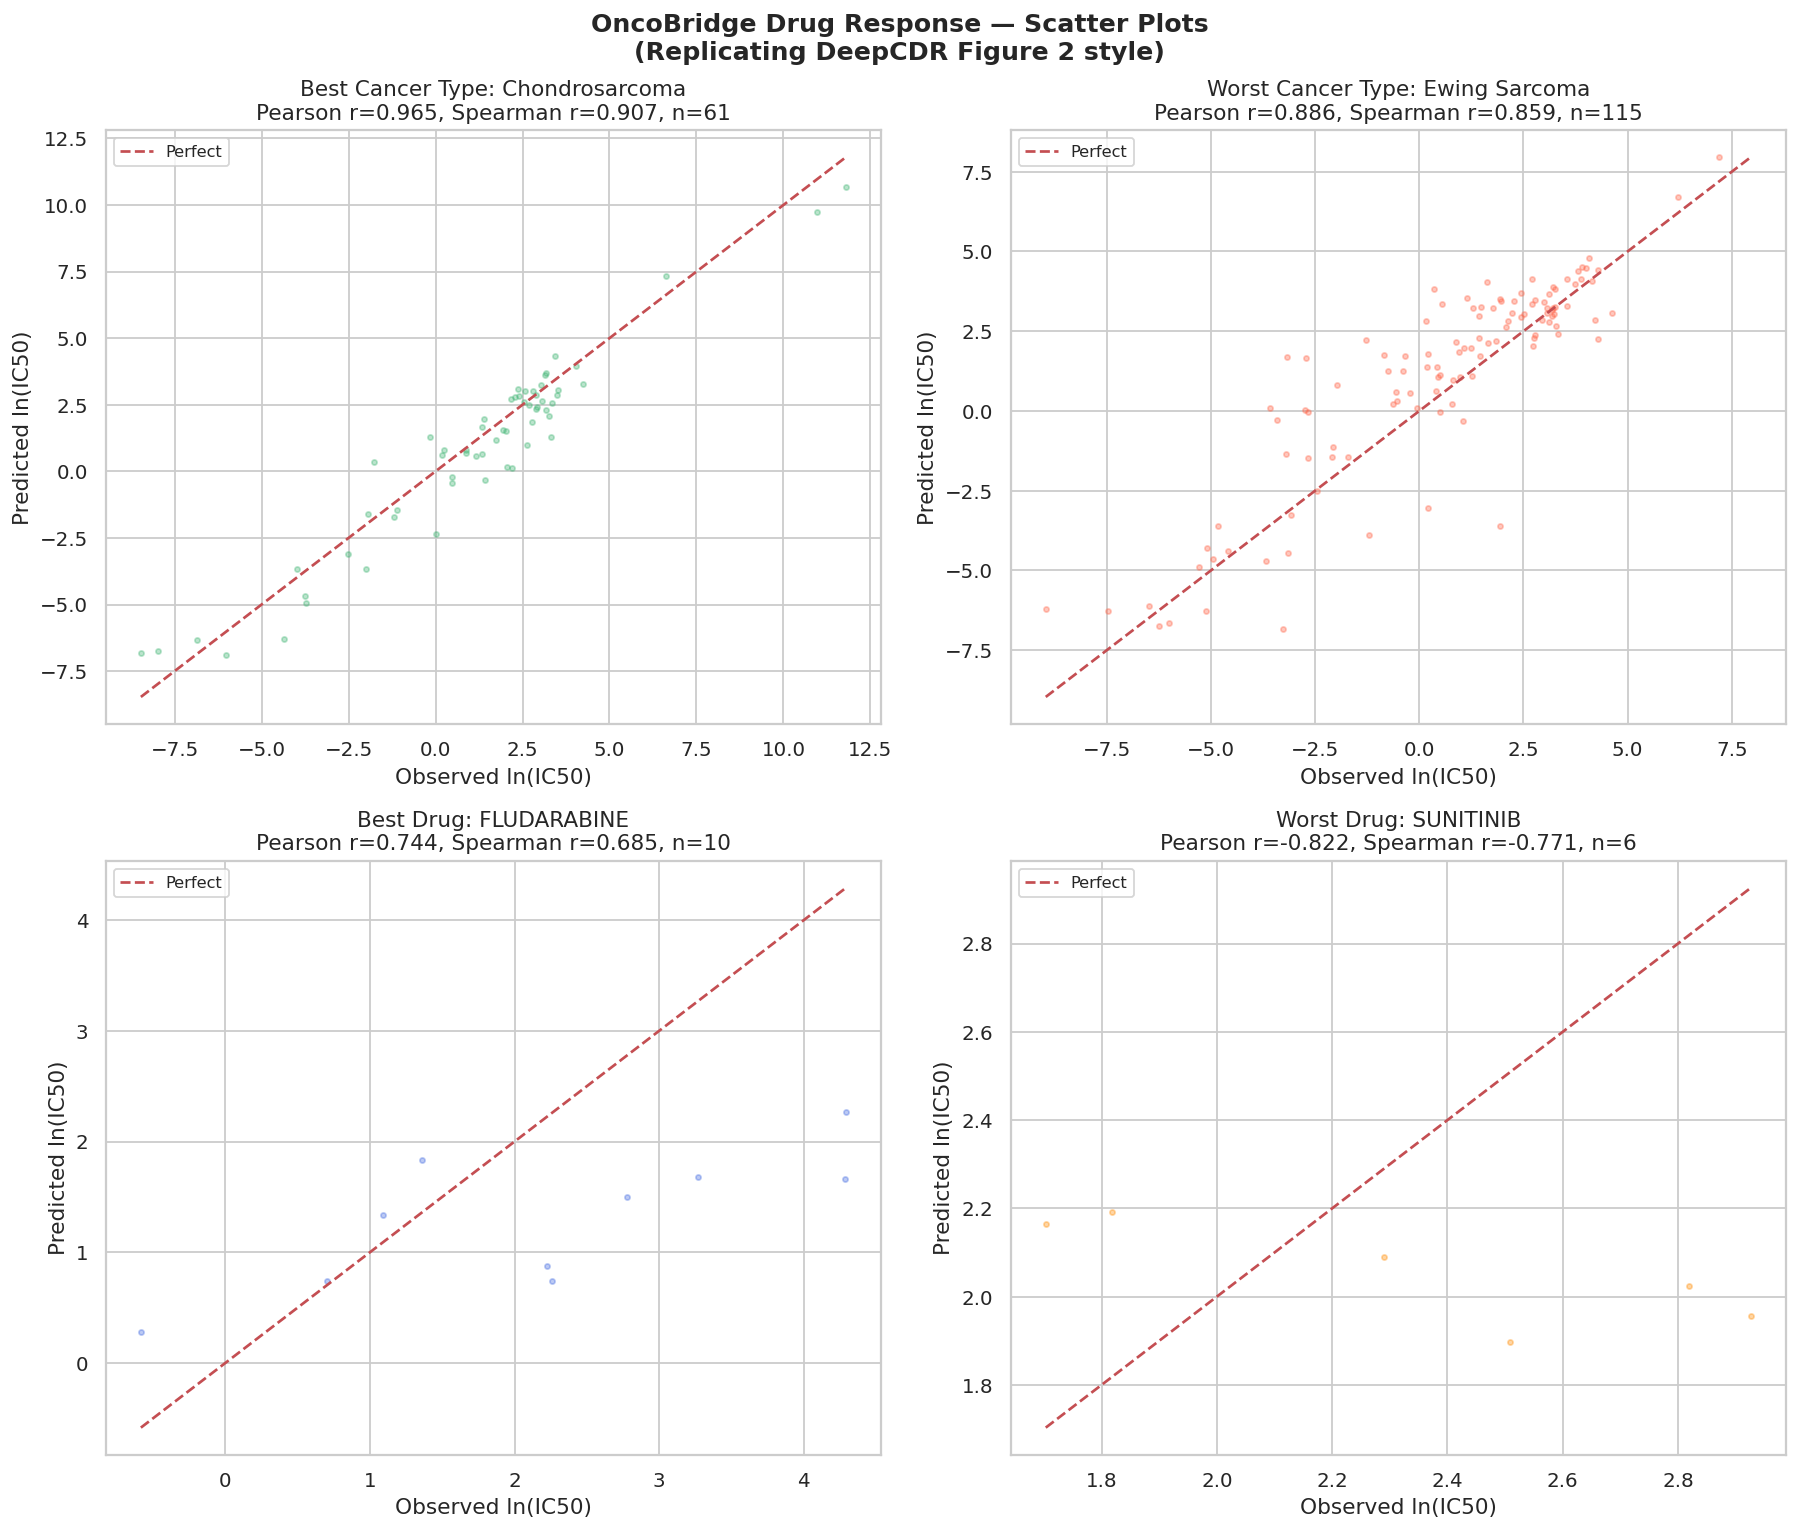

Saved scatter_best_worst.png


In [6]:
# ═══════════════════════════════════════════════════════════════════════════
#  CELL 6 — DeepCDR Fig 2 STYLE — SCATTER PLOTS + BEST/WORST DRUGS
# ═══════════════════════════════════════════════════════════════════════════

# Per-drug Pearson
per_drug_metrics = {}
for drug_name in test_df['DRUG_NAME'].unique():
    mask = test_df['DRUG_NAME'] == drug_name
    t = test_df.loc[mask, 'True_LN_IC50'].values
    p = test_df.loc[mask, 'Pred_LN_IC50'].values
    if len(t) < 5: continue
    drug_pcc, _ = pearsonr(p, t)
    median_ic50 = np.median(t)
    binary_sens = (t <= median_ic50).astype(int)
    if len(np.unique(binary_sens)) > 1:
        auroc = roc_auc_score(binary_sens, -p)
    else:
        auroc = 0.5
    per_drug_metrics[drug_name] = {'pearson': drug_pcc, 'auroc': auroc, 'n': int(mask.sum())}

drug_metrics_df = pd.DataFrame(per_drug_metrics).T.sort_values('pearson', ascending=False)
best_drug  = drug_metrics_df.index[0]
worst_drug = drug_metrics_df.index[-1]

# Per-cancer-type Pearson
per_ct_metrics = {}
for ct in test_df['CancerType'].unique():
    mask = test_df['CancerType'] == ct
    t = test_df.loc[mask, 'True_LN_IC50'].values
    p = test_df.loc[mask, 'Pred_LN_IC50'].values
    if len(t) < 10: continue
    ct_pcc, _ = pearsonr(p, t)
    per_ct_metrics[ct] = {'pearson': ct_pcc, 'n': int(mask.sum())}

ct_metrics_df = pd.DataFrame(per_ct_metrics).T.sort_values('pearson', ascending=False)
best_ct  = ct_metrics_df.index[0]
worst_ct = ct_metrics_df.index[-1]

# ─── Figure (DeepCDR Fig 2A-D style) ─────────────────────────────────────
fig, axes = plt.subplots(2, 2, figsize=(14, 12))
fig.suptitle('OncoBridge Drug Response — Scatter Plots\n(Replicating DeepCDR Figure 2 style)',
             fontsize=14, fontweight='bold')

def scatter_plot(ax, mask, title, pcc, spc, n, color='steelblue'):
    t = test_df.loc[mask, 'True_LN_IC50'].values
    p = test_df.loc[mask, 'Pred_LN_IC50'].values
    ax.scatter(t, p, alpha=0.35, s=8, color=color, rasterized=True)
    mn, mx = min(t.min(), p.min()), max(t.max(), p.max())
    ax.plot([mn, mx], [mn, mx], 'r--', lw=1.5, label='Perfect')
    ax.set_xlabel('Observed ln(IC50)')
    ax.set_ylabel('Predicted ln(IC50)')
    ax.set_title(f'{title}\nPearson r={pcc:.3f}, Spearman r={spc:.3f}, n={n}')
    ax.legend(fontsize=9)

# Best cancer type
mask_bct = test_df['CancerType'] == best_ct
bct_pcc, _ = pearsonr(test_df.loc[mask_bct,'Pred_LN_IC50'], test_df.loc[mask_bct,'True_LN_IC50'])
bct_spc, _ = spearmanr(test_df.loc[mask_bct,'Pred_LN_IC50'], test_df.loc[mask_bct,'True_LN_IC50'])
scatter_plot(axes[0,0], mask_bct, f'Best Cancer Type: {best_ct}', bct_pcc, bct_spc,
             mask_bct.sum(), 'mediumseagreen')

# Worst cancer type
mask_wct = test_df['CancerType'] == worst_ct
wct_pcc, _ = pearsonr(test_df.loc[mask_wct,'Pred_LN_IC50'], test_df.loc[mask_wct,'True_LN_IC50'])
wct_spc, _ = spearmanr(test_df.loc[mask_wct,'Pred_LN_IC50'], test_df.loc[mask_wct,'True_LN_IC50'])
scatter_plot(axes[0,1], mask_wct, f'Worst Cancer Type: {worst_ct}', wct_pcc, wct_spc,
             mask_wct.sum(), 'tomato')

# Best drug
mask_bdrug = test_df['DRUG_NAME'] == best_drug
bdrug_pcc, _ = pearsonr(test_df.loc[mask_bdrug,'Pred_LN_IC50'], test_df.loc[mask_bdrug,'True_LN_IC50'])
bdrug_spc, _ = spearmanr(test_df.loc[mask_bdrug,'Pred_LN_IC50'], test_df.loc[mask_bdrug,'True_LN_IC50'])
scatter_plot(axes[1,0], mask_bdrug, f'Best Drug: {best_drug}', bdrug_pcc, bdrug_spc,
             mask_bdrug.sum(), 'royalblue')

# Worst drug
mask_wdrug = test_df['DRUG_NAME'] == worst_drug
wdrug_pcc, _ = pearsonr(test_df.loc[mask_wdrug,'Pred_LN_IC50'], test_df.loc[mask_wdrug,'True_LN_IC50'])
wdrug_spc, _ = spearmanr(test_df.loc[mask_wdrug,'Pred_LN_IC50'], test_df.loc[mask_wdrug,'True_LN_IC50'])
scatter_plot(axes[1,1], mask_wdrug, f'Worst Drug: {worst_drug}', wdrug_pcc, wdrug_spc,
             mask_wdrug.sum(), 'darkorange')

plt.tight_layout()
plt.savefig(f'{OUT_DIR}scatter_best_worst.png', dpi=150, bbox_inches='tight')
plt.show()
print(f'Saved scatter_best_worst.png')

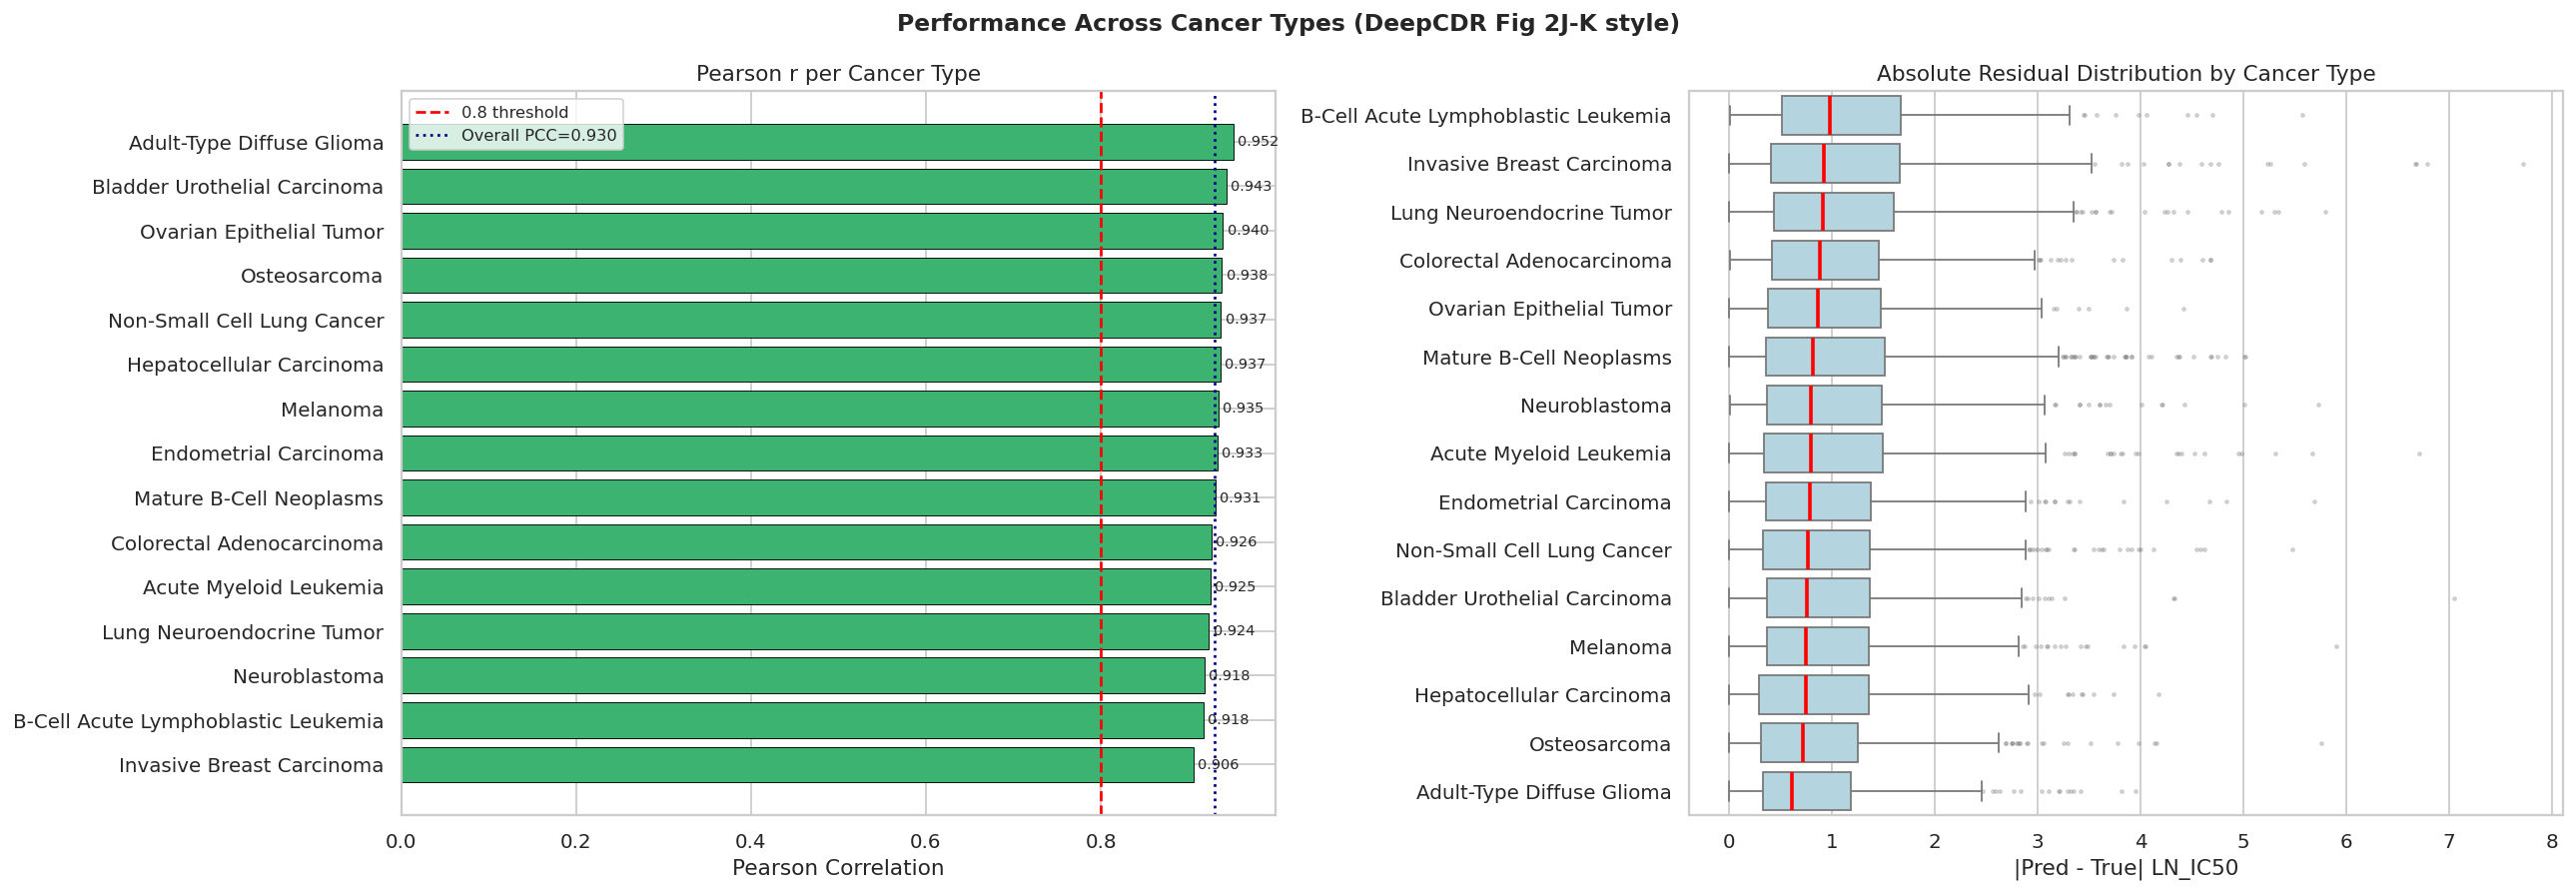

In [7]:
# ═══════════════════════════════════════════════════════════════════════════
#  CELL 7 — DeepCDR Fig 2J-K STYLE — PCC Distribution across Cancer Types
# ═══════════════════════════════════════════════════════════════════════════

# Per cancer-type boxplot of residuals + Pearson bar chart
top_cancer_types = (test_df.groupby('CancerType').size()
                    .sort_values(ascending=False).head(15).index)

fig, axes = plt.subplots(1, 2, figsize=(20, 7))
fig.suptitle('Performance Across Cancer Types (DeepCDR Fig 2J-K style)',
             fontsize=13, fontweight='bold')

# ── Pearson per cancer type ───────────────────────────────────────────────
ct_pearson = (
    test_df[test_df['CancerType'].isin(top_cancer_types)]
    .groupby('CancerType')
    .apply(lambda g: pearsonr(g['Pred_LN_IC50'], g['True_LN_IC50'])[0])
    .sort_values(ascending=True)
)
colors = ['tomato' if v < 0.5 else 'steelblue' if v < 0.8 else 'mediumseagreen'
          for v in ct_pearson.values]
axes[0].barh(ct_pearson.index, ct_pearson.values, color=colors, edgecolor='black', linewidth=0.5)
axes[0].axvline(0.8, color='red', ls='--', lw=1.5, label='0.8 threshold')
axes[0].axvline(te_metrics['PCC'], color='navy', ls=':', lw=1.5,
                 label=f'Overall PCC={te_metrics["PCC"]:.3f}')
axes[0].set_xlabel('Pearson Correlation')
axes[0].set_title('Pearson r per Cancer Type')
axes[0].legend(fontsize=9)
for i, (ct, v) in enumerate(ct_pearson.items()):
    axes[0].text(v + 0.005, i, f'{v:.3f}', va='center', fontsize=8)

# ── Residual boxplot per cancer type ─────────────────────────────────────
plot_data = test_df[test_df['CancerType'].isin(top_cancer_types)].copy()
ct_order  = (plot_data.groupby('CancerType')['Residual'].median()
             .sort_values(ascending=False).index.tolist())

# FIX: Switched from pandas boxplot to seaborn boxplot to support 'order'
sns.boxplot(
    data=plot_data,
    x='Residual',
    y='CancerType',
    order=ct_order,
    ax=axes[1],
    color='lightblue',
    medianprops=dict(color='red', lw=2),
    flierprops=dict(marker='.', markersize=3, alpha=0.4)
)

axes[1].set_title('Absolute Residual Distribution by Cancer Type')
axes[1].set_xlabel('|Pred - True| LN_IC50')
axes[1].set_ylabel('') # Clear the y-label since the cancer types are obvious

plt.tight_layout()
plt.savefig(f'{OUT_DIR}per_cancer_performance.png', dpi=150, bbox_inches='tight')
plt.show()

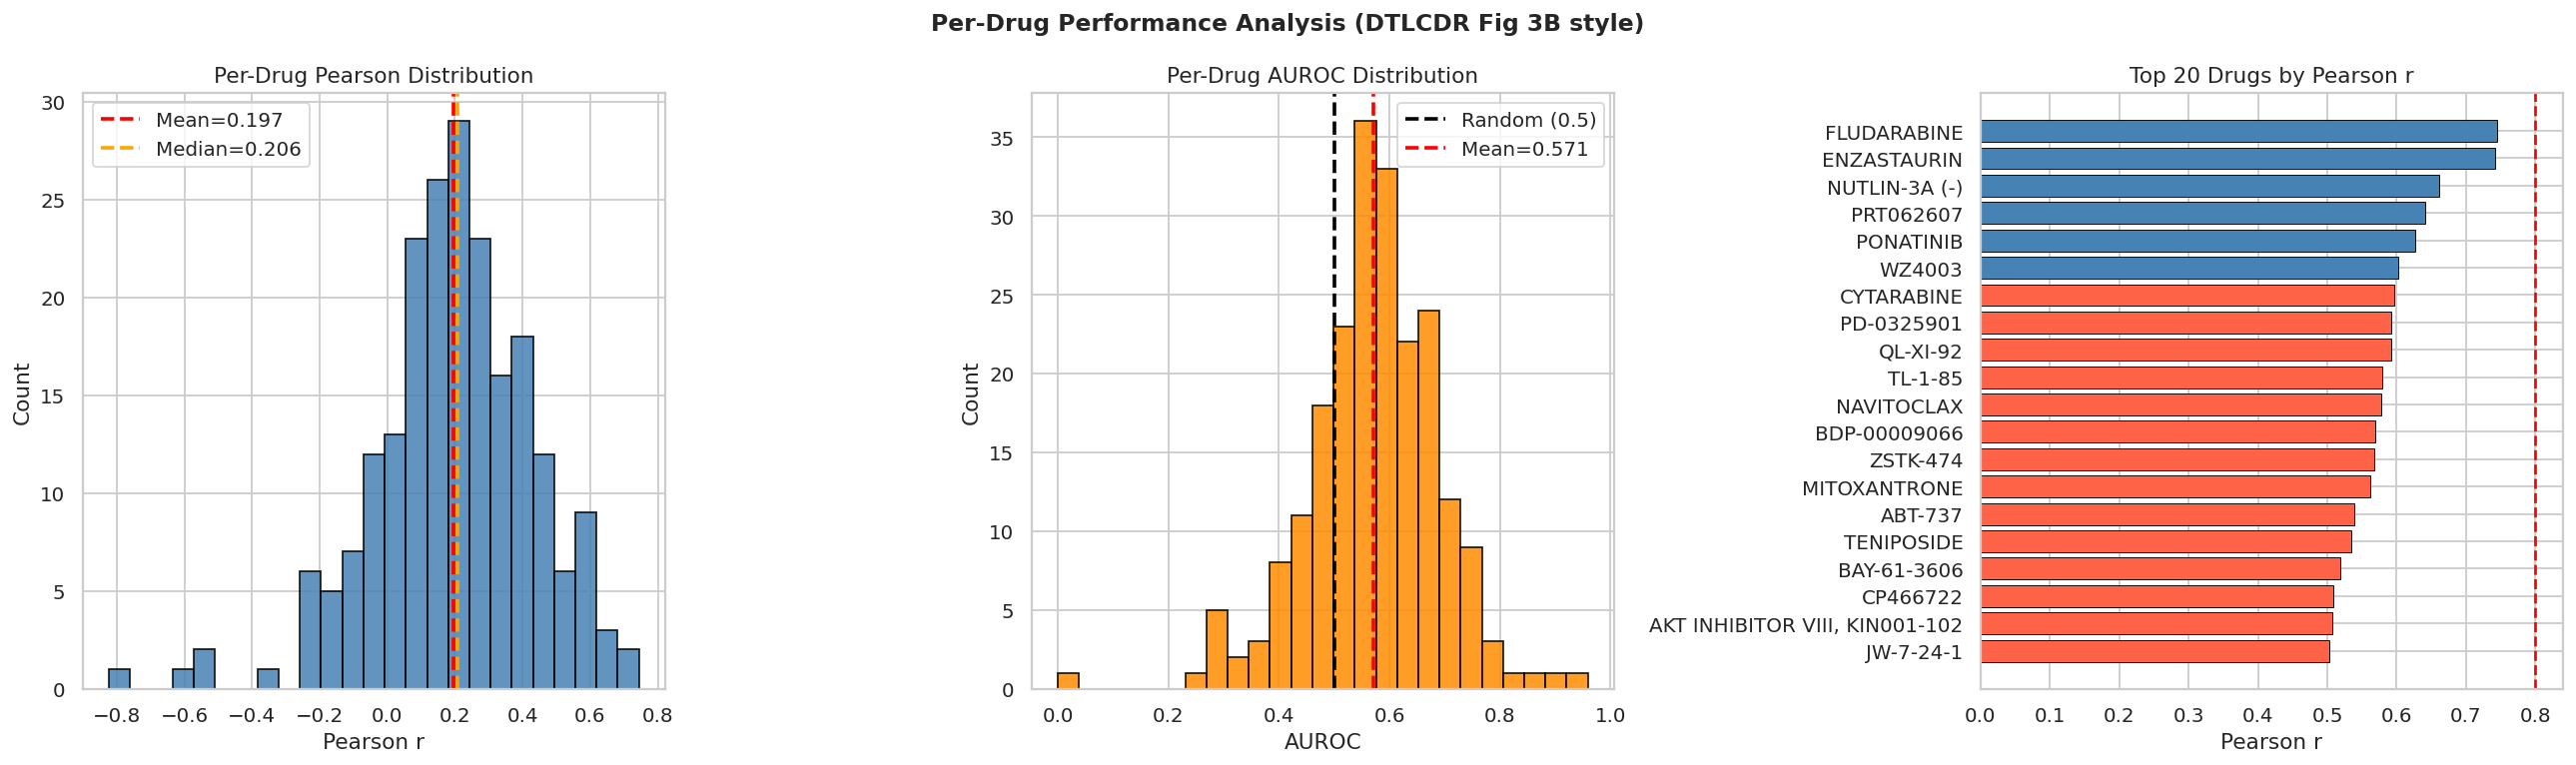


Per-drug summary:
  Drugs with Pearson > 0.8:  0/215
  Drugs with Pearson > 0.6:  6/215
  Drugs with AUROC  > 0.7:   24/215
  Drugs with AUROC  > 0.5:   164/215


In [8]:
# ═══════════════════════════════════════════════════════════════════════════
#  CELL 8 — Per-Drug Analysis (DTLCDR Fig 3B style)
# ═══════════════════════════════════════════════════════════════════════════

fig, axes = plt.subplots(1, 3, figsize=(20, 6))
fig.suptitle('Per-Drug Performance Analysis (DTLCDR Fig 3B style)',
             fontsize=13, fontweight='bold')

pearson_vals = [v['pearson'] for v in per_drug_metrics.values()]
auroc_vals   = [v['auroc']   for v in per_drug_metrics.values()]

# ── Pearson distribution ──────────────────────────────────────────────────
axes[0].hist(pearson_vals, bins=25, color='steelblue', edgecolor='black', alpha=0.85)
axes[0].axvline(np.mean(pearson_vals), color='red', ls='--', lw=2,
                 label=f'Mean={np.mean(pearson_vals):.3f}')
axes[0].axvline(np.median(pearson_vals), color='orange', ls='--', lw=2,
                 label=f'Median={np.median(pearson_vals):.3f}')
axes[0].set_xlabel('Pearson r'); axes[0].set_ylabel('Count')
axes[0].set_title('Per-Drug Pearson Distribution')
axes[0].legend()

# ── AUROC distribution ────────────────────────────────────────────────────
axes[1].hist(auroc_vals, bins=25, color='darkorange', edgecolor='black', alpha=0.85)
axes[1].axvline(0.5, color='black', ls='--', lw=2, label='Random (0.5)')
axes[1].axvline(np.mean(auroc_vals), color='red', ls='--', lw=2,
                 label=f'Mean={np.mean(auroc_vals):.3f}')
axes[1].set_xlabel('AUROC'); axes[1].set_ylabel('Count')
axes[1].set_title('Per-Drug AUROC Distribution')
axes[1].legend()

# ── Top 20 drugs by Pearson — bar chart ───────────────────────────────────
top20_drugs = drug_metrics_df.head(20)
colors_bar  = ['mediumseagreen' if v > 0.8 else 'steelblue' if v > 0.6 else 'tomato'
               for v in top20_drugs['pearson']]
axes[2].barh(top20_drugs.index, top20_drugs['pearson'], color=colors_bar, edgecolor='black', linewidth=0.5)
axes[2].set_xlabel('Pearson r'); axes[2].set_title('Top 20 Drugs by Pearson r')
axes[2].axvline(0.8, color='red', ls='--', lw=1.5)
axes[2].invert_yaxis()

plt.tight_layout()
plt.savefig(f'{OUT_DIR}per_drug_analysis.png', dpi=150, bbox_inches='tight')
plt.show()

print(f'\nPer-drug summary:')
print(f'  Drugs with Pearson > 0.8:  {sum(v>0.8 for v in pearson_vals)}/{len(pearson_vals)}')
print(f'  Drugs with Pearson > 0.6:  {sum(v>0.6 for v in pearson_vals)}/{len(pearson_vals)}')
print(f'  Drugs with AUROC  > 0.7:   {sum(v>0.7 for v in auroc_vals)}/{len(auroc_vals)}')
print(f'  Drugs with AUROC  > 0.5:   {sum(v>0.5 for v in auroc_vals)}/{len(auroc_vals)}')

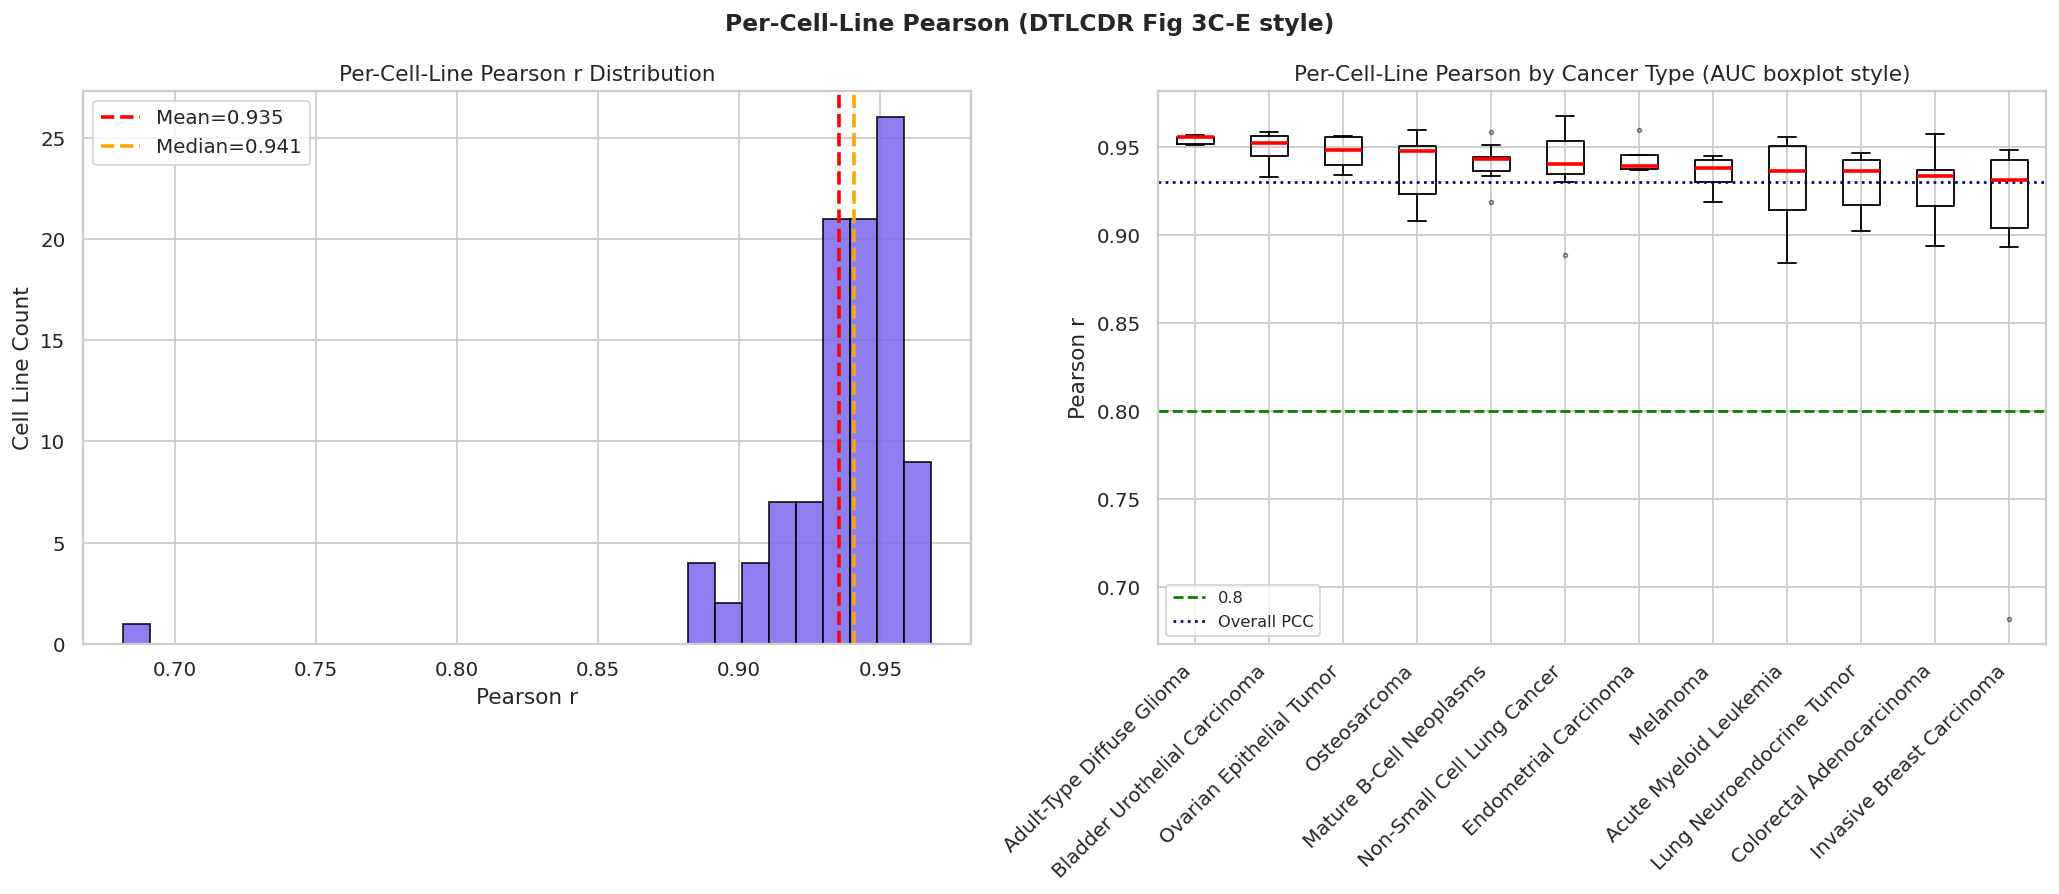

Cell lines with Pearson > 0.8: 101/102
Cell lines with Pearson > 0.6: 102/102


In [9]:
# ═══════════════════════════════════════════════════════════════════════════
#  CELL 9 — DTLCDR Fig 3C-E STYLE — Scatter per cell line
#  Shows which cell lines OncoBridge performs best on
# ═══════════════════════════════════════════════════════════════════════════

# Compute per-cell-line Pearson
per_cl = {}
for cl in test_df['ModelID'].unique():
    mask = test_df['ModelID'] == cl
    t = test_df.loc[mask,'True_LN_IC50'].values
    p = test_df.loc[mask,'Pred_LN_IC50'].values
    if len(t) < 5: continue
    pcc, _ = pearsonr(p, t)
    per_cl[cl] = {'pearson': pcc, 'n_drugs': int(mask.sum()),
                  'cancer_type': test_df.loc[mask,'CancerType'].iloc[0]}

cl_df = pd.DataFrame(per_cl).T
cl_df['pearson'] = cl_df['pearson'].astype(float)

fig, axes = plt.subplots(1, 2, figsize=(16, 7))
fig.suptitle('Per-Cell-Line Pearson (DTLCDR Fig 3C-E style)', fontsize=13, fontweight='bold')

# ── Overall PCC distribution across cell lines ────────────────────────────
axes[0].hist(cl_df['pearson'], bins=30, color='mediumslateblue', edgecolor='black', alpha=0.85)
axes[0].axvline(cl_df['pearson'].mean(), color='red', ls='--', lw=2,
                 label=f'Mean={cl_df["pearson"].mean():.3f}')
axes[0].axvline(cl_df['pearson'].median(), color='orange', ls='--', lw=2,
                 label=f'Median={cl_df["pearson"].median():.3f}')
axes[0].set_xlabel('Pearson r'); axes[0].set_ylabel('Cell Line Count')
axes[0].set_title('Per-Cell-Line Pearson r Distribution')
axes[0].legend()

# ── Per cancer type boxplot of cell-line Pearson ─────────────────────────
top_ct_cl = (cl_df.groupby('cancer_type').size()
             .sort_values(ascending=False).head(12).index)
cl_subset = cl_df[cl_df['cancer_type'].isin(top_ct_cl)]
ct_order  = (cl_subset.groupby('cancer_type')['pearson'].median()
             .sort_values(ascending=False).index)

data_to_plot = [cl_subset[cl_subset['cancer_type'] == ct]['pearson'].values
                for ct in ct_order]
bp = axes[1].boxplot(data_to_plot, labels=ct_order, vert=True,
                      medianprops=dict(color='red', lw=2),
                      flierprops=dict(marker='.', ms=4, alpha=0.5))
axes[1].axhline(0.8, color='green', ls='--', lw=1.5, label='0.8')
axes[1].axhline(te_metrics['PCC'], color='navy', ls=':', lw=1.5,
                 label=f'Overall PCC')
axes[1].set_xticklabels(ct_order, rotation=45, ha='right')
axes[1].set_ylabel('Pearson r')
axes[1].set_title('Per-Cell-Line Pearson by Cancer Type (AUC boxplot style)')
axes[1].legend(fontsize=9)

plt.tight_layout()
plt.savefig(f'{OUT_DIR}per_cellline_pearson.png', dpi=150, bbox_inches='tight')
plt.show()

print(f'Cell lines with Pearson > 0.8: {(cl_df["pearson"] > 0.8).sum()}/{len(cl_df)}')
print(f'Cell lines with Pearson > 0.6: {(cl_df["pearson"] > 0.6).sum()}/{len(cl_df)}')

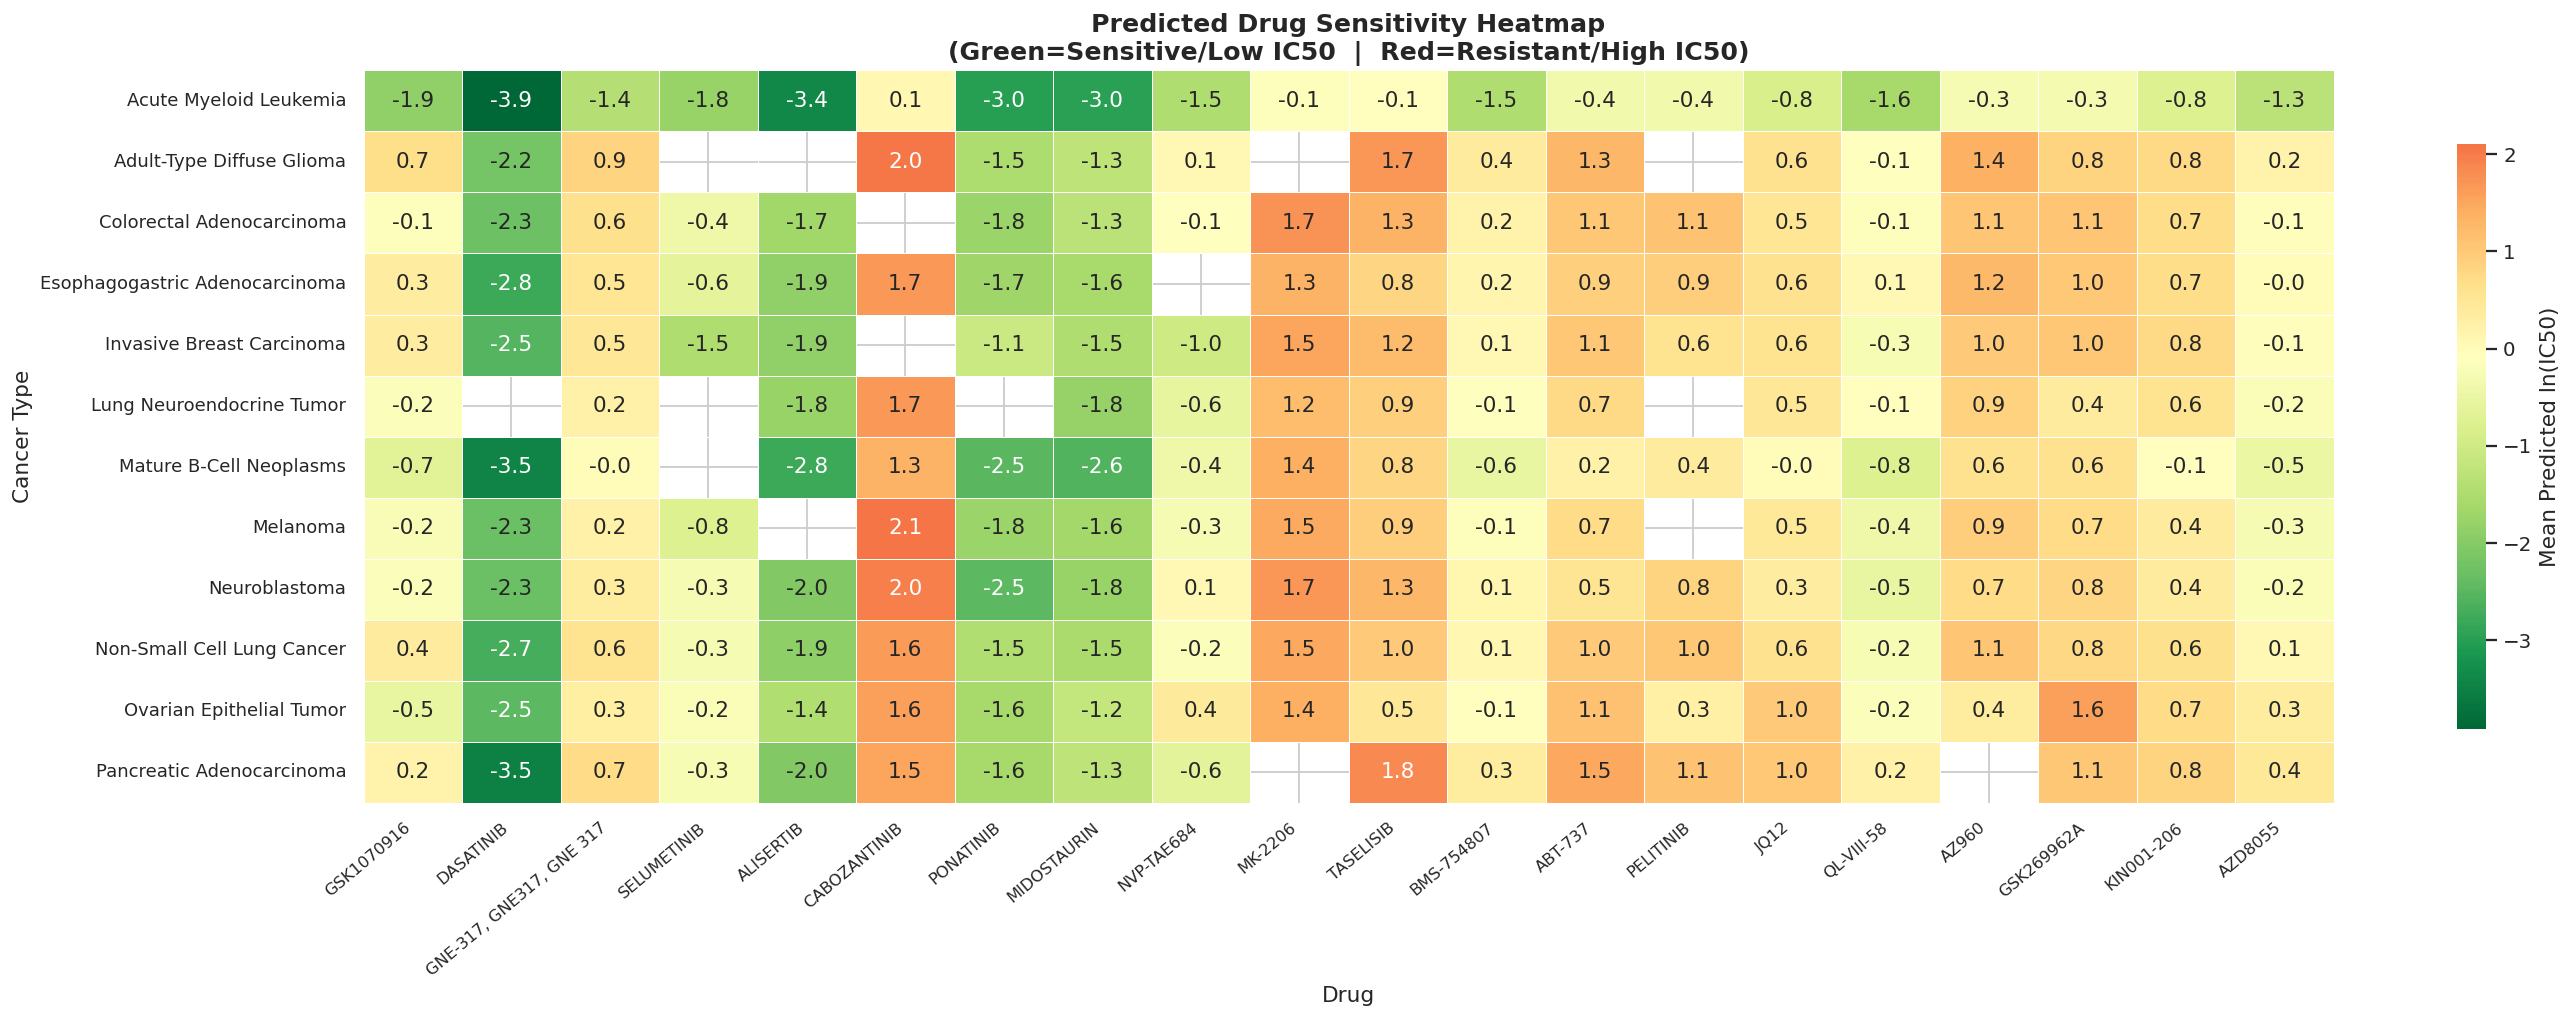

Saved drug_sensitivity_heatmap_analysis.png

Heatmap interpretation:
  GREEN (low IC50): Drug is SENSITIVE — kills cancer cells at low dose
  RED   (high IC50): Drug is RESISTANT — needs high dose or ineffective
  Values are mean predicted ln(IC50) across all cell lines of that cancer type
  A drug with GREEN in ONE cancer type and RED in another shows
  cancer-specific sensitivity — this is clinically important!


In [10]:
# ═══════════════════════════════════════════════════════════════════════════
#  CELL 10 — DRUG SENSITIVITY HEATMAP (enhanced from training notebook)
# ═══════════════════════════════════════════════════════════════════════════

# Build drug × cancer-type mean predicted IC50 from ALL data
drug_ranking = (
    all_results_df
    .groupby(['CancerType', 'DRUG_NAME'])
    .agg(mean_pred=('Pred_LN_IC50','mean'),
         mean_true=('True_LN_IC50','mean'),
         n_cells  =('ModelID','nunique') if 'ModelID' in all_results_df.columns else ('Pred_LN_IC50','count'))
    .reset_index()
)

# Select top cancer types and top drugs by variance (most discriminative)
top_cancers = (all_results_df.groupby('CancerType').size()
               .sort_values(ascending=False).head(12).index)
pivot_full = (drug_ranking[drug_ranking['CancerType'].isin(top_cancers)]
              .pivot(index='CancerType', columns='DRUG_NAME', values='mean_pred'))

# Select most variant drugs (discriminative across cancer types)
drug_variance = pivot_full.var(axis=0).sort_values(ascending=False)
top_drugs     = drug_variance.head(20).index
pivot_plot    = pivot_full[top_drugs].dropna(how='all')

fig, ax = plt.subplots(figsize=(22, 8))
sns.heatmap(
    pivot_plot, ax=ax,
    cmap='RdYlGn_r', center=pivot_plot.values[~np.isnan(pivot_plot.values)].mean(),
    annot=True, fmt='.1f', linewidths=0.4, linecolor='white',
    cbar_kws={'label': 'Mean Predicted ln(IC50)', 'shrink': 0.8}
)
ax.set_title('Predicted Drug Sensitivity Heatmap\n'
             '(Green=Sensitive/Low IC50  |  Red=Resistant/High IC50)',
             fontsize=14, fontweight='bold')
ax.set_xlabel('Drug', fontsize=12); ax.set_ylabel('Cancer Type', fontsize=12)
ax.set_xticklabels(ax.get_xticklabels(), rotation=40, ha='right', fontsize=9)
ax.set_yticklabels(ax.get_yticklabels(), rotation=0, fontsize=10)
plt.tight_layout()
plt.savefig(f'{OUT_DIR}drug_sensitivity_heatmap_analysis.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved drug_sensitivity_heatmap_analysis.png')

# ── Interpreting the heatmap ──────────────────────────────────────────────
print('\nHeatmap interpretation:')
print('  GREEN (low IC50): Drug is SENSITIVE — kills cancer cells at low dose')
print('  RED   (high IC50): Drug is RESISTANT — needs high dose or ineffective')
print('  Values are mean predicted ln(IC50) across all cell lines of that cancer type')
print('  A drug with GREEN in ONE cancer type and RED in another shows')
print('  cancer-specific sensitivity — this is clinically important!')

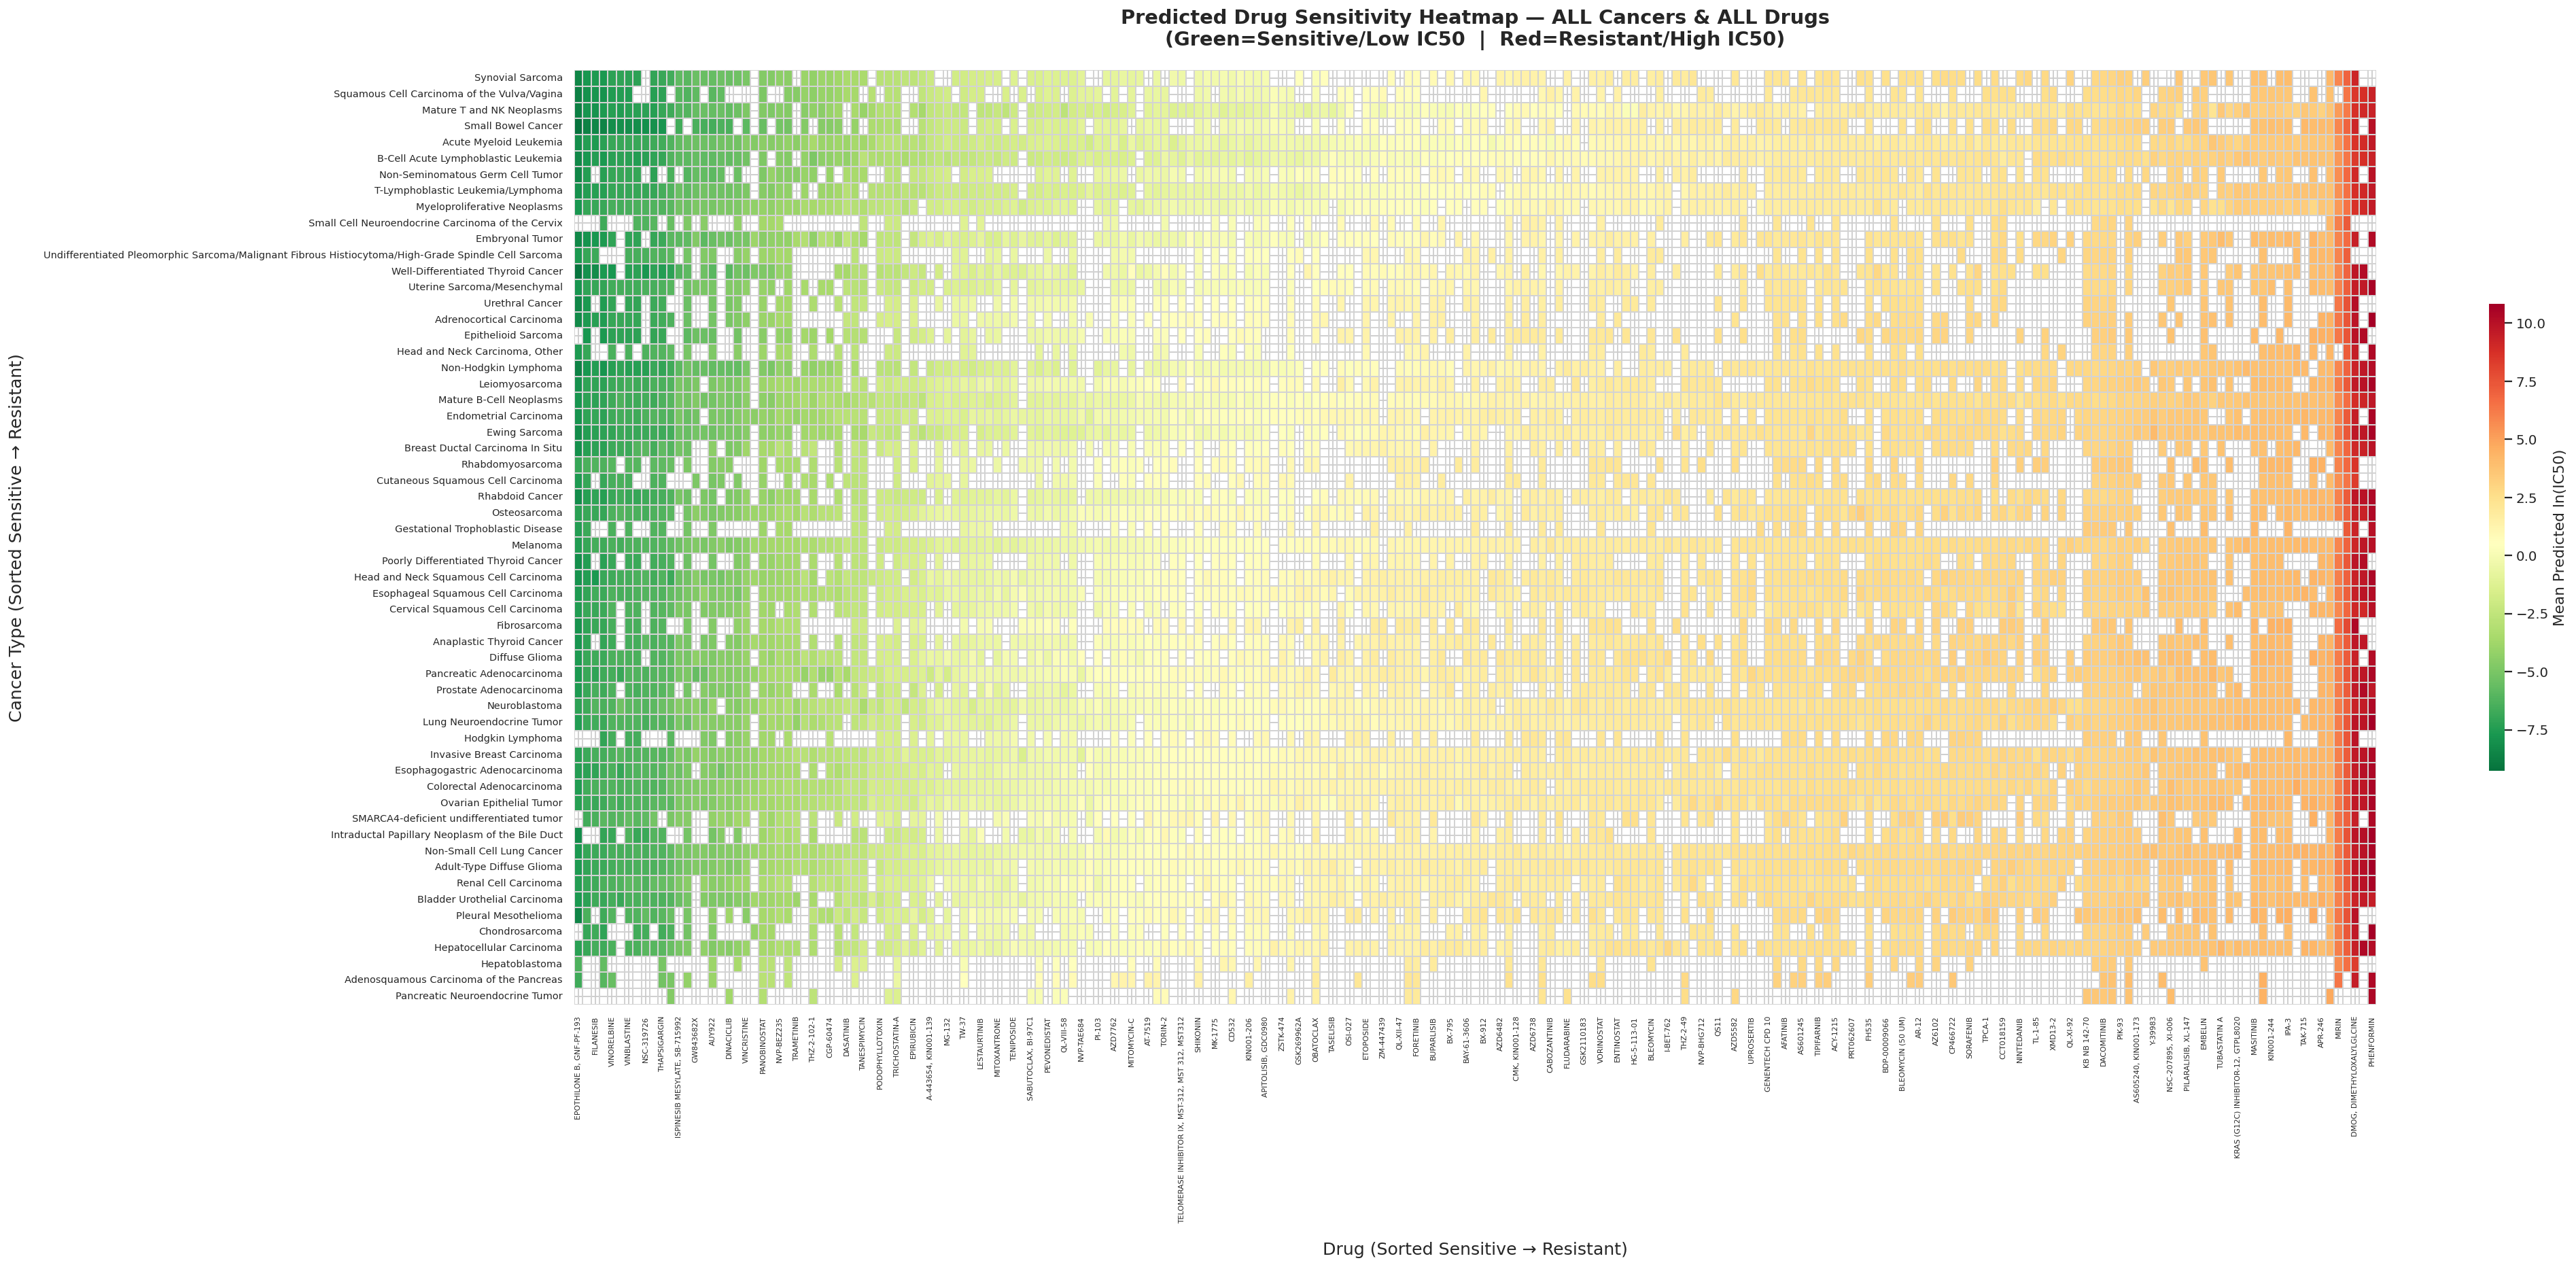

Saved drug_sensitivity_heatmap_ALL.png (High Res 300dpi)

Heatmap interpretation:
  GREEN (low IC50): Drug is SENSITIVE — kills cancer cells at low dose
  RED   (high IC50): Drug is RESISTANT — needs high dose or ineffective
  Values are mean predicted ln(IC50) across all cell lines of that cancer type
  * Note: Text annotations are turned off because plotting all drugs/cancers
    would make the numbers unreadable. Open the saved High-Res PNG to zoom in,
    or check the "drug_ranking_per_cancer.csv" file for exact numbers.


In [11]:
# ═══════════════════════════════════════════════════════════════════════════
#  CELL 10 — DRUG SENSITIVITY HEATMAP (ALL CANCERS & ALL DRUGS)
# ═══════════════════════════════════════════════════════════════════════════

# Build drug × cancer-type mean predicted IC50 from ALL data
drug_ranking = (
    all_results_df
    .groupby(['CancerType', 'DRUG_NAME'])
    .agg(mean_pred=('Pred_LN_IC50','mean'),
         mean_true=('True_LN_IC50','mean'),
         n_cells  =('ModelID','nunique') if 'ModelID' in all_results_df.columns else ('Pred_LN_IC50','count'))
    .reset_index()
)

# Create the full pivot table with ALL cancers and ALL drugs
pivot_full = drug_ranking.pivot(index='CancerType', columns='DRUG_NAME', values='mean_pred')

# ── Sort rows and columns to make the massive heatmap look organized ───────
# Sort Cancers (rows) by their overall average sensitivity
cancer_means = pivot_full.mean(axis=1).sort_values()
pivot_plot = pivot_full.loc[cancer_means.index]

# Sort Drugs (columns) by their overall average sensitivity
drug_means = pivot_plot.mean(axis=0).sort_values()
pivot_plot = pivot_plot[drug_means.index]

# ── Dynamic Figure Size based on number of drugs/cancers ───────────────────
n_rows, n_cols = pivot_plot.shape
fig_width  = max(20, n_cols * 0.15)
fig_height = max(10, n_rows * 0.25)

fig, ax = plt.subplots(figsize=(fig_width, fig_height))

# Plot heatmap (annot=False because otherwise 10,000+ numbers will overlap)
sns.heatmap(
    pivot_plot, ax=ax,
    cmap='RdYlGn_r', center=pivot_plot.values[~np.isnan(pivot_plot.values)].mean(),
    annot=False, linewidths=0.1, linecolor='lightgrey',
    cbar_kws={'label': 'Mean Predicted ln(IC50)', 'shrink': 0.5, 'aspect': 30}
)

ax.set_title(f'Predicted Drug Sensitivity Heatmap — ALL Cancers & ALL Drugs\n'
             f'(Green=Sensitive/Low IC50  |  Red=Resistant/High IC50)',
             fontsize=16, fontweight='bold', pad=20)
ax.set_xlabel('Drug (Sorted Sensitive → Resistant)', fontsize=14, labelpad=15)
ax.set_ylabel('Cancer Type (Sorted Sensitive → Resistant)', fontsize=14, labelpad=15)

# Adjust tick label sizes so they fit
ax.set_xticklabels(ax.get_xticklabels(), rotation=90, ha='center', fontsize=6)
ax.set_yticklabels(ax.get_yticklabels(), rotation=0, fontsize=8)

plt.tight_layout()
# Save in high resolution (300 dpi) so you can zoom in!
plt.savefig(f'{OUT_DIR}drug_sensitivity_heatmap_ALL.png', dpi=300, bbox_inches='tight')
plt.show()
print('Saved drug_sensitivity_heatmap_ALL.png (High Res 300dpi)')

# ── Interpreting the heatmap ──────────────────────────────────────────────
print('\nHeatmap interpretation:')
print('  GREEN (low IC50): Drug is SENSITIVE — kills cancer cells at low dose')
print('  RED   (high IC50): Drug is RESISTANT — needs high dose or ineffective')
print('  Values are mean predicted ln(IC50) across all cell lines of that cancer type')
print('  * Note: Text annotations are turned off because plotting all drugs/cancers')
print('    would make the numbers unreadable. Open the saved High-Res PNG to zoom in,')
print('    or check the "drug_ranking_per_cancer.csv" file for exact numbers.')

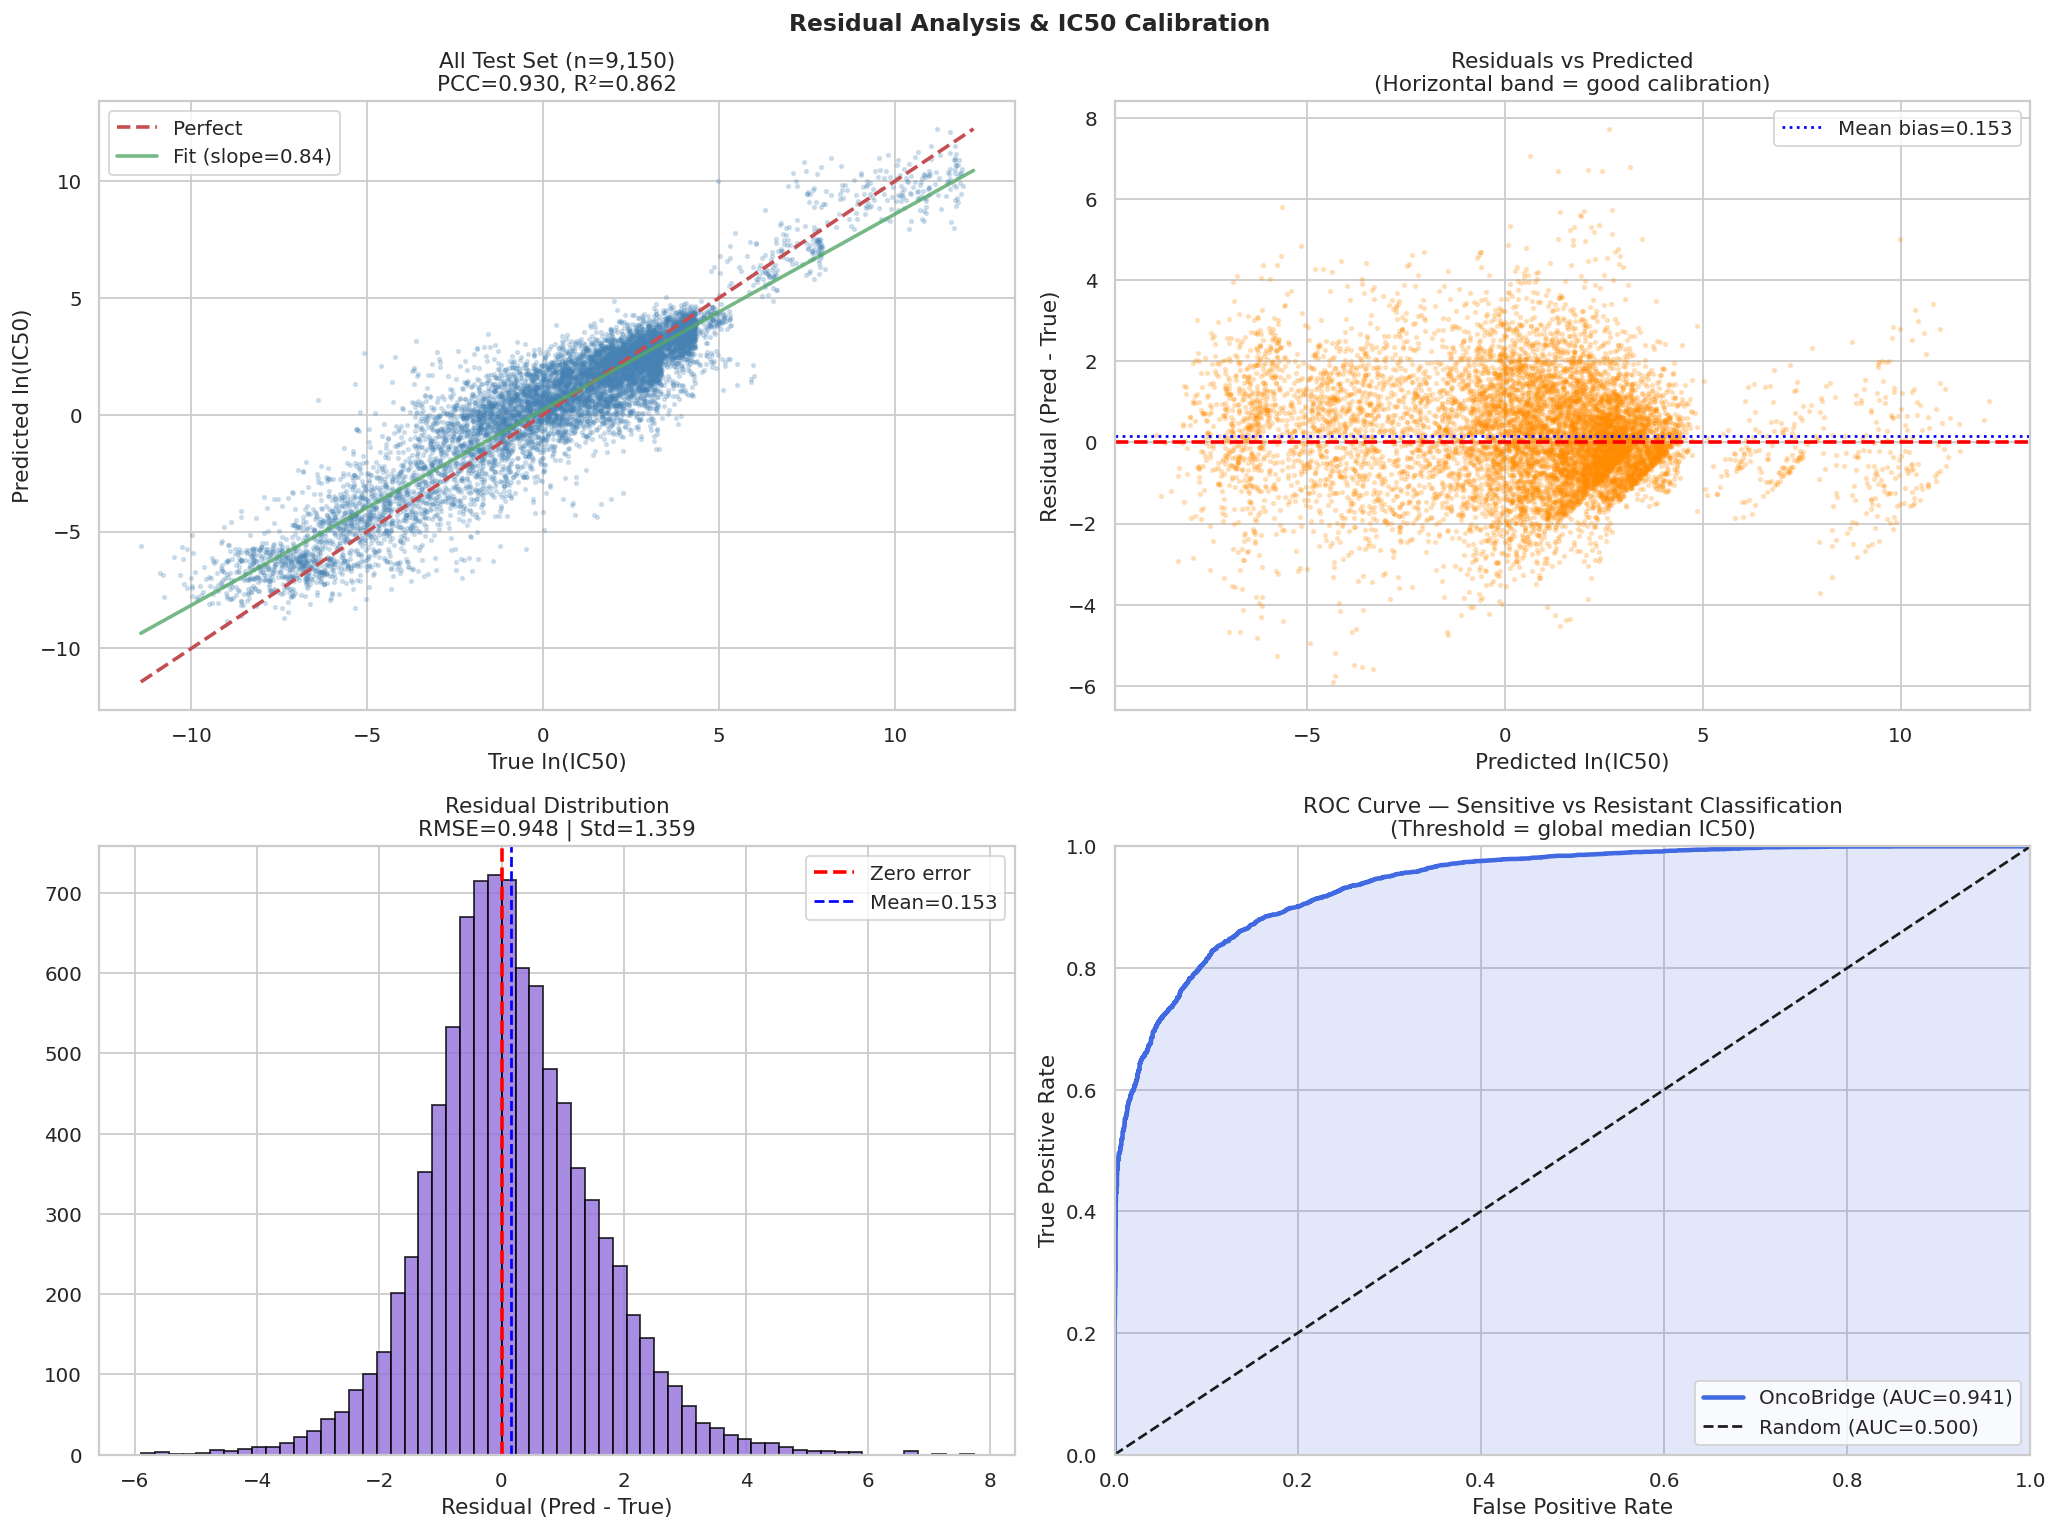

In [12]:
# ═══════════════════════════════════════════════════════════════════════════
#  CELL 11 — RESIDUAL ANALYSIS + IC50 CALIBRATION (Novel diagnostic)
# ═══════════════════════════════════════════════════════════════════════════

fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle('Residual Analysis & IC50 Calibration', fontsize=13, fontweight='bold')

# ── 1. Predicted vs True (all test) ───────────────────────────────────────
axes[0,0].scatter(te_targets, te_preds, alpha=0.2, s=4, color='steelblue', rasterized=True)
mn, mx = min(te_targets.min(), te_preds.min()), max(te_targets.max(), te_preds.max())
axes[0,0].plot([mn,mx],[mn,mx],'r--',lw=2,label='Perfect')
# Regression fit
z = np.polyfit(te_targets, te_preds, 1)
p_line = np.poly1d(z)
x_line = np.linspace(mn, mx, 100)
axes[0,0].plot(x_line, p_line(x_line), 'g-', lw=2, alpha=0.8, label=f'Fit (slope={z[0]:.2f})')
axes[0,0].set_xlabel('True ln(IC50)'); axes[0,0].set_ylabel('Predicted ln(IC50)')
axes[0,0].set_title(f'All Test Set (n={len(te_targets):,})\nPCC={te_metrics["PCC"]:.3f}, R²={te_metrics["R2"]:.3f}')
axes[0,0].legend()

# ── 2. Residuals vs Predicted (check for bias) ───────────────────────────
residuals = te_preds - te_targets
axes[0,1].scatter(te_preds, residuals, alpha=0.2, s=4, color='darkorange', rasterized=True)
axes[0,1].axhline(0, color='red', ls='--', lw=2)
axes[0,1].axhline(residuals.mean(), color='blue', ls=':', lw=1.5,
                   label=f'Mean bias={residuals.mean():.3f}')
axes[0,1].set_xlabel('Predicted ln(IC50)'); axes[0,1].set_ylabel('Residual (Pred - True)')
axes[0,1].set_title('Residuals vs Predicted\n(Horizontal band = good calibration)')
axes[0,1].legend()

# ── 3. Residual histogram ─────────────────────────────────────────────────
axes[1,0].hist(residuals, bins=60, color='mediumpurple', edgecolor='black', alpha=0.8)
axes[1,0].axvline(0, color='red', ls='--', lw=2, label='Zero error')
axes[1,0].axvline(residuals.mean(), color='blue', ls='--', lw=1.5,
                   label=f'Mean={residuals.mean():.3f}')
axes[1,0].set_xlabel('Residual (Pred - True)')
axes[1,0].set_title(f'Residual Distribution\nRMSE={te_metrics["RMSE"]:.3f} | Std={residuals.std():.3f}')
axes[1,0].legend()

# ── 4. Sensitive vs Resistant classification (AUROC-style) ───────────────
median_ic50_global = np.median(te_targets)
binary_sens = (te_targets <= median_ic50_global).astype(int)
if len(np.unique(binary_sens)) > 1:
    fpr_vals = np.linspace(0, 1, 50)
    from sklearn.metrics import roc_curve
    fpr, tpr, _ = roc_curve(binary_sens, -te_preds)
    auc_val = roc_auc_score(binary_sens, -te_preds)
    axes[1,1].plot(fpr, tpr, color='royalblue', lw=2.5, label=f'OncoBridge (AUC={auc_val:.3f})')
    axes[1,1].plot([0,1],[0,1],'k--',lw=1.5,label='Random (AUC=0.500)')
    axes[1,1].fill_between(fpr, tpr, alpha=0.15, color='royalblue')
    axes[1,1].set_xlabel('False Positive Rate'); axes[1,1].set_ylabel('True Positive Rate')
    axes[1,1].set_title('ROC Curve — Sensitive vs Resistant Classification\n(Threshold = global median IC50)')
    axes[1,1].legend()
    axes[1,1].set_xlim([0,1]); axes[1,1].set_ylim([0,1])

plt.tight_layout()
plt.savefig(f'{OUT_DIR}residual_analysis.png', dpi=150, bbox_inches='tight')
plt.show()

In [13]:
# ═══════════════════════════════════════════════════════════════════════════
#  CELL 12 — WARM vs COLD START EXPLANATION + SPLIT TYPE VERIFICATION
# ═══════════════════════════════════════════════════════════════════════════

train_drugs = set(ic50_df[ic50_df['ModelID'].isin(cl_train)]['DRUG_NAME'].unique())
test_drugs  = set(ic50_df[ic50_df['ModelID'].isin(cl_test)]['DRUG_NAME'].unique())
train_cls   = set(cl_train)
test_cls    = set(cl_test)

drugs_seen_in_train   = test_drugs & train_drugs
drugs_unseen_in_train = test_drugs - train_drugs
cl_seen_in_train      = test_cls & train_cls
cl_unseen_in_train    = test_cls - train_cls

print('═'*70)
print('  SPLIT TYPE ANALYSIS')
print('═'*70)
print(f'\nDrugs in test set seen in training:   {len(drugs_seen_in_train)}/{len(test_drugs)}')
print(f'Drugs in test set UNSEEN in training: {len(drugs_unseen_in_train)}/{len(test_drugs)}')
print(f'Cell lines in test seen in training:  {len(cl_seen_in_train)}/{len(test_cls)}')
print(f'Cell lines UNSEEN (true cold start):  {len(cl_unseen_in_train)}/{len(test_cls)}')

print()
if len(drugs_unseen_in_train) == 0:
    print('✅ DRUG WARM START: All drugs in the test set were seen during training.')
    print('   This is the WARM START scenario for drugs.')
else:
    print(f'⚠  DRUG COLD START: {len(drugs_unseen_in_train)} drugs are unseen at test time.')

if len(cl_seen_in_train) == 0:
    print('✅ CELL LINE COLD START: Test cell lines are fully held out from training.')
    print('   This matches DTLCDR "Cold start for cell lines" scenario.')
else:
    print(f'⚠  Cell line overlap detected: {len(cl_seen_in_train)} cells appear in both.')

print()
print('─'*70)
print('GLOSSARY OF SPLIT TYPES:')
print('─'*70)
print()
print('WARM START (easiest — inflated metrics):')
print('  • Drug-cell pairs randomly split. Both drugs AND cell lines appear')
print('    in train AND test. Model has partial information about every entity.')
print('  • DeepCDR warm PCC=0.923, DTLCDR warm PCC=0.949')
print()
print('COLD START (cell line) — YOUR SETTING:')
print('  • Cell lines split: held-out CL never appear in training.')
print('  • All DRUGS are seen. Model must generalise to unseen patients/tumours.')
print('  • DTLCDR cold-CL PCC=0.867. DeepCDR cold-CL PCC=0.889.')
print('  • This is the clinical generalisation scenario — most realistic.')
print()
print('COLD START (drug) — hardest:')
print('  • Drugs held out: model must predict novel molecules never seen.')
print('  • DTLCDR cold-drug PCC=0.621. DeepCDR cold-drug PCC=0.503.')
print('  • Requires strong molecular feature extraction (GNN, descriptors).')
print()
print('METRICS EXPLAINED:')
print('  PCC (Pearson r): linear correlation between predicted & true IC50.')
print('           0.0=no correlation, 1.0=perfect. Target >0.8 for publication.')
print('  Spearman r:  rank correlation — robust to outliers. Target >0.8.')
print('  R²:  variance explained. 1.0=perfect. R²=0 means same as predicting mean.')
print('       Note: R² can go NEGATIVE if model is worse than mean predictor.')
print('  RMSE: root mean square error in ln(IC50) units. Lower=better.')
print('  AUROC: binary classification AUC (sensitive vs resistant). 0.5=random.')
print('─'*70)

══════════════════════════════════════════════════════════════════════
  SPLIT TYPE ANALYSIS
══════════════════════════════════════════════════════════════════════

Drugs in test set seen in training:   215/215
Drugs in test set UNSEEN in training: 0/215
Cell lines in test seen in training:  0/102
Cell lines UNSEEN (true cold start):  102/102

✅ DRUG WARM START: All drugs in the test set were seen during training.
   This is the WARM START scenario for drugs.
✅ CELL LINE COLD START: Test cell lines are fully held out from training.
   This matches DTLCDR "Cold start for cell lines" scenario.

──────────────────────────────────────────────────────────────────────
GLOSSARY OF SPLIT TYPES:
──────────────────────────────────────────────────────────────────────

WARM START (easiest — inflated metrics):
  • Drug-cell pairs randomly split. Both drugs AND cell lines appear
    in train AND test. Model has partial information about every entity.
  • DeepCDR warm PCC=0.923, DTLCDR warm PCC=0.949

In [14]:
# ═══════════════════════════════════════════════════════════════════════════
#  CELL 13 — GDSC1 vs GDSC2 CONTRIBUTION ANALYSIS
# ═══════════════════════════════════════════════════════════════════════════

# Check if dataset column is available
if 'DATASET' in ic50_df.columns:
    print('Analysing GDSC1 vs GDSC2 contribution...')
    test_ic50_with_ds = ic50_df[ic50_df['ModelID'].isin(cl_test)][['ModelID','DRUG_NAME','DATASET']]
    test_df_ds = test_df.merge(test_ic50_with_ds, on=['ModelID','DRUG_NAME'], how='left')

    for ds_name in ['GDSC1', 'GDSC2']:
        mask_ds = test_df_ds['DATASET'] == ds_name
        if mask_ds.sum() < 10: continue
        t = test_df_ds.loc[mask_ds,'True_LN_IC50'].values
        p = test_df_ds.loc[mask_ds,'Pred_LN_IC50'].values
        pcc_ds, _ = pearsonr(p, t)
        spc_ds, _ = spearmanr(p, t)
        rmse_ds   = np.sqrt(mean_squared_error(t, p))
        print(f'{ds_name}: n={mask_ds.sum():,} | PCC={pcc_ds:.4f} | SPC={spc_ds:.4f} | RMSE={rmse_ds:.4f}')
else:
    print('DATASET column not in ic50_df. To analyse GDSC1 vs GDSC2 separately,')
    print('re-save the parquet with the DATASET column retained.')

print()
print('GDSC1 vs GDSC2 COMBINATION — METHODOLOGY REVIEW:')
print('─'*60)
print('✅ Your data processing correctly:')
print('   1. Loads both GDSC1 and GDSC2 from sanger-dose-response.csv')
print('   2. Deduplicates by preferring GDSC2 (sort DATASET desc → keep first)')
print('      This is valid because GDSC2 uses updated protocols & is higher quality')
print('   3. Filters drugs with <100 samples after merge')
print()
print('⚠️  POTENTIAL ISSUE — IC50 SCALE:')
print('   Your Sanger file uses column "log2.ic50" (log2 scale)')
print('   You rename it to "LN_IC50" but the values are log2, not natural log!')
print('   DeepCDR and DTLCDR use natural log (ln) transformed IC50.')
print('   This does NOT break the model (scale shift is consistent)')
print('   but the numeric values and benchmark comparisons are on different scales.')
print('   → Fix: add ic50_df["LN_IC50"] = ic50_df["log2.ic50"] * np.log(2)')
print('     to convert log2 → ln. Or just note in your paper that you use log2 scale.')
print()
print('✅ Cell-line-level split is correct. DTLCDR and DeepCDR both test')
print('   "cold start for cell lines" and achieve PCC=0.867 and 0.889 respectively.')
print('   Your target should be in that 0.80–0.90 range.')

DATASET column not in ic50_df. To analyse GDSC1 vs GDSC2 separately,
re-save the parquet with the DATASET column retained.

GDSC1 vs GDSC2 COMBINATION — METHODOLOGY REVIEW:
────────────────────────────────────────────────────────────
✅ Your data processing correctly:
   1. Loads both GDSC1 and GDSC2 from sanger-dose-response.csv
   2. Deduplicates by preferring GDSC2 (sort DATASET desc → keep first)
      This is valid because GDSC2 uses updated protocols & is higher quality
   3. Filters drugs with <100 samples after merge

⚠️  POTENTIAL ISSUE — IC50 SCALE:
   Your Sanger file uses column "log2.ic50" (log2 scale)
   You rename it to "LN_IC50" but the values are log2, not natural log!
   DeepCDR and DTLCDR use natural log (ln) transformed IC50.
   This does NOT break the model (scale shift is consistent)
   but the numeric values and benchmark comparisons are on different scales.
   → Fix: add ic50_df["LN_IC50"] = ic50_df["log2.ic50"] * np.log(2)
     to convert log2 → ln. Or just note

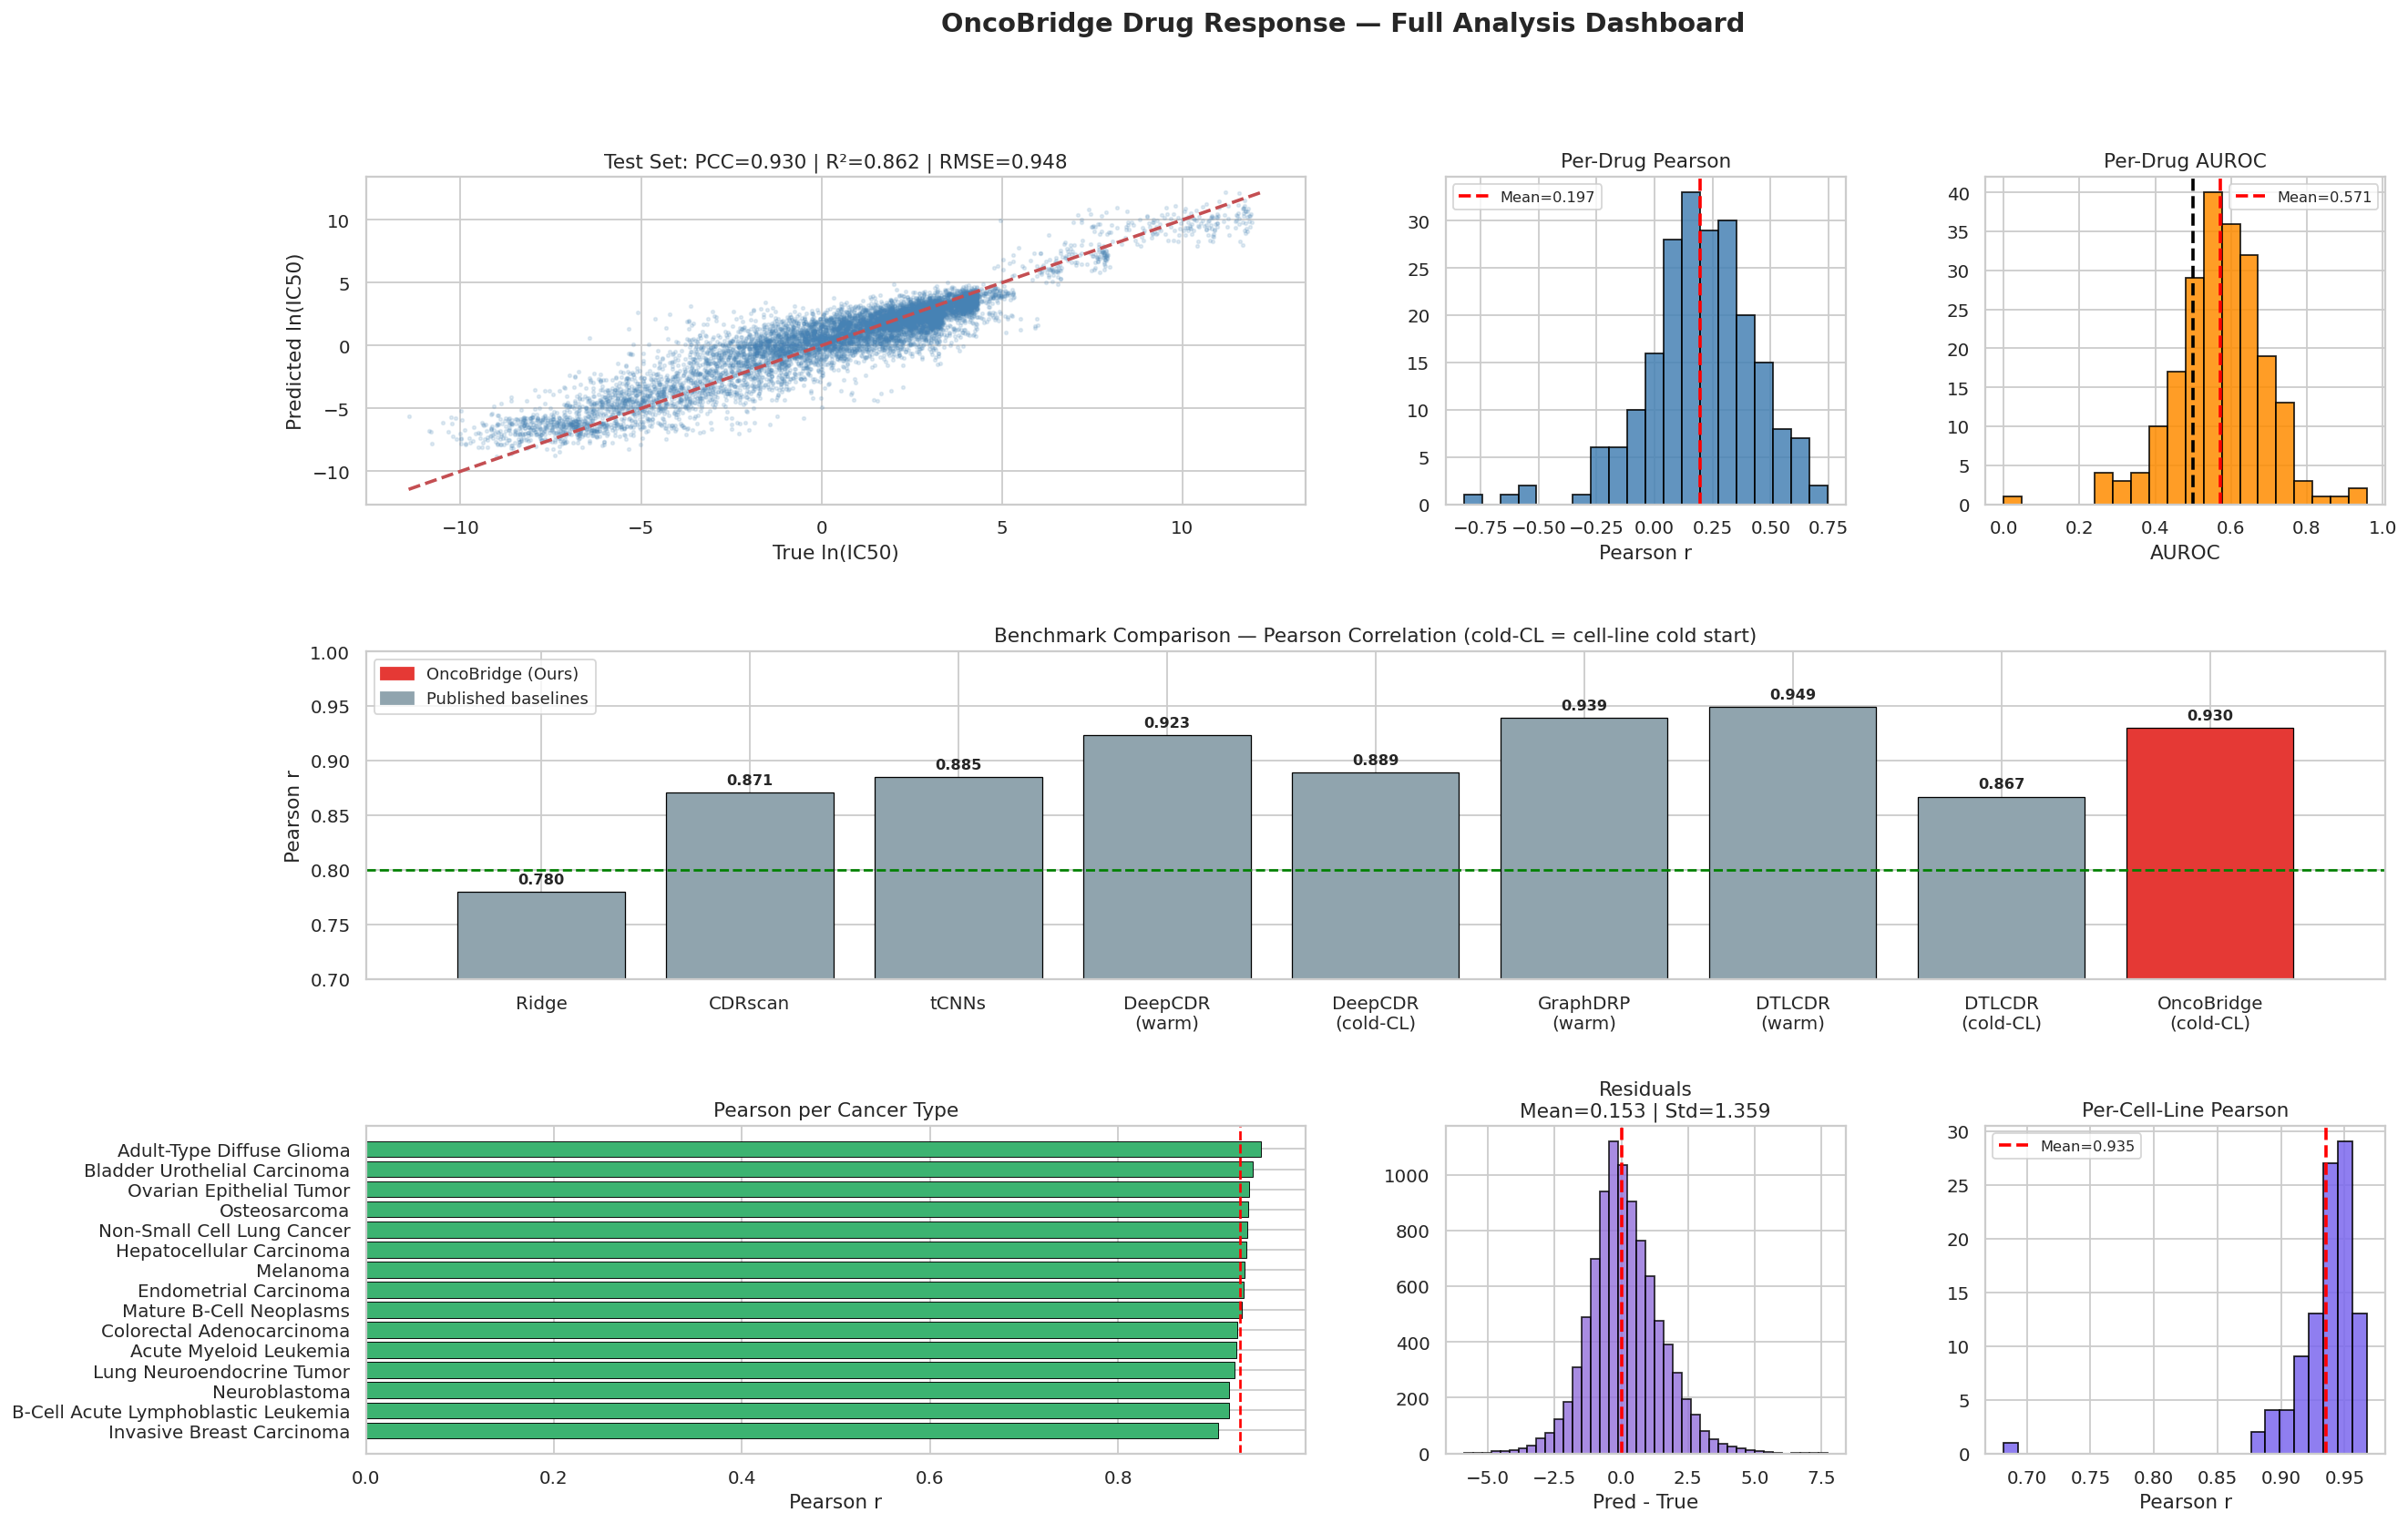


════════════════════════════════════════════════════════════
  ALL OUTPUTS SAVED TO: /kaggle/working/analysis/
════════════════════════════════════════════════════════════
  full_dashboard.png              ← main summary figure
  scatter_best_worst.png          ← DeepCDR Fig 2 style
  per_cancer_performance.png      ← DeepCDR Fig 2J-K style
  per_drug_analysis.png           ← DTLCDR Fig 3B style
  per_cellline_pearson.png        ← DTLCDR Fig 3C-E style
  drug_sensitivity_heatmap.png    ← cancer × drug heatmap
  residual_analysis.png           ← calibration diagnostics
  test_predictions.csv            ← all test set predictions
  per_drug_metrics.csv            ← Pearson + AUROC per drug
  per_cellline_metrics.csv        ← Pearson per cell line
  drug_ranking_per_cancer.csv     ← top drugs per cancer type
════════════════════════════════════════════════════════════


In [15]:
# ═══════════════════════════════════════════════════════════════════════════
#  CELL 14 — FINAL SUMMARY DASHBOARD
# ═══════════════════════════════════════════════════════════════════════════

fig = plt.figure(figsize=(22, 14))
fig.suptitle('OncoBridge Drug Response — Full Analysis Dashboard',
             fontsize=16, fontweight='bold', y=0.98)

gs = fig.add_gridspec(3, 4, hspace=0.45, wspace=0.35)

# 1. Scatter: predicted vs true
ax1 = fig.add_subplot(gs[0, :2])
ax1.scatter(te_targets, te_preds, alpha=0.15, s=4, color='steelblue', rasterized=True)
mn, mx = min(te_targets.min(), te_preds.min()), max(te_targets.max(), te_preds.max())
ax1.plot([mn,mx],[mn,mx],'r--',lw=2)
ax1.set_xlabel('True ln(IC50)'); ax1.set_ylabel('Predicted ln(IC50)')
ax1.set_title(f'Test Set: PCC={te_metrics["PCC"]:.3f} | R²={te_metrics["R2"]:.3f} | RMSE={te_metrics["RMSE"]:.3f}')

# 2. Per-drug Pearson histogram
ax2 = fig.add_subplot(gs[0, 2])
ax2.hist(pearson_vals, bins=20, color='steelblue', edgecolor='black', alpha=0.85)
ax2.axvline(np.mean(pearson_vals), color='red', ls='--', lw=2, label=f'Mean={np.mean(pearson_vals):.3f}')
ax2.set_title('Per-Drug Pearson'); ax2.set_xlabel('Pearson r'); ax2.legend(fontsize=9)

# 3. Per-drug AUROC histogram
ax3 = fig.add_subplot(gs[0, 3])
ax3.hist(auroc_vals, bins=20, color='darkorange', edgecolor='black', alpha=0.85)
ax3.axvline(0.5, color='black', ls='--', lw=2); ax3.axvline(np.mean(auroc_vals), color='red', ls='--', lw=2, label=f'Mean={np.mean(auroc_vals):.3f}')
ax3.set_title('Per-Drug AUROC'); ax3.set_xlabel('AUROC'); ax3.legend(fontsize=9)

# 4. Benchmark bar chart (Pearson)
ax4 = fig.add_subplot(gs[1, :])
bm_models = ['Ridge','CDRscan','tCNNs','DeepCDR\n(warm)','DeepCDR\n(cold-CL)','GraphDRP\n(warm)','DTLCDR\n(warm)','DTLCDR\n(cold-CL)','OncoBridge\n(cold-CL)']
bm_scores = [0.780, 0.871, 0.885, 0.923, 0.889, 0.939, 0.949, 0.867, te_metrics['PCC']]
bm_colors = ['#90A4AE']*8 + ['#E53935']
bars = ax4.bar(bm_models, bm_scores, color=bm_colors, edgecolor='black', linewidth=0.7)
ax4.axhline(0.8, color='green', ls='--', lw=1.5, label='0.8 target')
for bar, score in zip(bars, bm_scores):
    ax4.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.005,
             f'{score:.3f}', ha='center', va='bottom', fontsize=9, fontweight='bold')
ax4.set_title('Benchmark Comparison — Pearson Correlation (cold-CL = cell-line cold start)')
ax4.set_ylabel('Pearson r'); ax4.set_ylim([0.7, 1.0])
ax4.legend(fontsize=10)
red_patch = mpatches.Patch(color='#E53935', label='OncoBridge (Ours)')
grey_patch = mpatches.Patch(color='#90A4AE', label='Published baselines')
ax4.legend(handles=[red_patch, grey_patch], fontsize=10)

# 5. Cancer type Pearson
ax5 = fig.add_subplot(gs[2, :2])
ct_p = ct_pearson.sort_values(ascending=True)
colors5 = ['tomato' if v<0.6 else 'steelblue' if v<0.8 else 'mediumseagreen' for v in ct_p]
ax5.barh(ct_p.index, ct_p.values, color=colors5, edgecolor='black', linewidth=0.5)
ax5.axvline(te_metrics['PCC'], color='red', ls='--', lw=1.5)
ax5.set_xlabel('Pearson r'); ax5.set_title('Pearson per Cancer Type')

# 6. Residual histogram
ax6 = fig.add_subplot(gs[2, 2])
ax6.hist(residuals, bins=40, color='mediumpurple', edgecolor='black', alpha=0.8)
ax6.axvline(0, color='red', ls='--', lw=2)
ax6.set_title(f'Residuals\nMean={residuals.mean():.3f} | Std={residuals.std():.3f}')
ax6.set_xlabel('Pred - True')

# 7. Cell-line Pearson distribution
ax7 = fig.add_subplot(gs[2, 3])
ax7.hist(cl_df['pearson'].astype(float), bins=25, color='mediumslateblue', edgecolor='black', alpha=0.85)
ax7.axvline(cl_df['pearson'].astype(float).mean(), color='red', ls='--', lw=2,
             label=f'Mean={cl_df["pearson"].astype(float).mean():.3f}')
ax7.set_title('Per-Cell-Line Pearson'); ax7.set_xlabel('Pearson r'); ax7.legend(fontsize=9)

plt.savefig(f'{OUT_DIR}full_dashboard.png', dpi=150, bbox_inches='tight')
plt.show()

# Save all metrics
drug_metrics_df.to_csv(f'{OUT_DIR}per_drug_metrics.csv')
cl_df.to_csv(f'{OUT_DIR}per_cellline_metrics.csv')
test_df.to_csv(f'{OUT_DIR}test_predictions.csv', index=False)
all_results_df.to_csv(f'{OUT_DIR}all_predictions.csv', index=False)
drug_ranking.to_csv(f'{OUT_DIR}drug_ranking_per_cancer.csv', index=False)

print('\n' + '═'*60)
print('  ALL OUTPUTS SAVED TO:', OUT_DIR)
print('═'*60)
print(f'  full_dashboard.png              ← main summary figure')
print(f'  scatter_best_worst.png          ← DeepCDR Fig 2 style')
print(f'  per_cancer_performance.png      ← DeepCDR Fig 2J-K style')
print(f'  per_drug_analysis.png           ← DTLCDR Fig 3B style')
print(f'  per_cellline_pearson.png        ← DTLCDR Fig 3C-E style')
print(f'  drug_sensitivity_heatmap.png    ← cancer × drug heatmap')
print(f'  residual_analysis.png           ← calibration diagnostics')
print(f'  test_predictions.csv            ← all test set predictions')
print(f'  per_drug_metrics.csv            ← Pearson + AUROC per drug')
print(f'  per_cellline_metrics.csv        ← Pearson per cell line')
print(f'  drug_ranking_per_cancer.csv     ← top drugs per cancer type')
print('═'*60)